In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from pathlib import Path

import numpy as np
import pandas as pd

from bloodmoon.io import simulation_files
from bloodmoon.mask import codedmask

import darksun as ds

from fract_shift2 import model_shadowgram, model_sky


def savefig_to(
    figpath: str | Path,
    name: str,
    frmt: str = 'png',
    overwrite: bool = False,
) -> str | Path | None:
    """
    Creates the filepath to save a Figure with the chosen format,
    and checks if the file already exists. If the file exists,
    `None` is returned to avoid the file overwriting. 
    """
    def is_img(filepath: Path) -> bool:
        """Checks if a file has been already saved."""
        return filepath.is_file()
    
    filepath = f'{figpath}/{name}.{frmt}'
    if (not is_img(Path(filepath))) or overwrite:
        return filepath
    return None

save_to = '/home/edoardo/Desktop/PSF_test'
save_things = True

In [2]:
skyfield = "GalacticCentre"
mask_FITS = "wfm_mask_NTHT_20250725.fits"
data_FITS = "galctr_rxte-sax_2-50keV_mask_050_1040x17_opaquemask_infdet"

N_TEST = "singleCAM_iros_testing_PSF_newModelSG"

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    run_name=N_TEST,
)

VIGNETTING = True
PSFY = False
UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = 'detected'

filepaths = simulation_files(simul_data)
sdlA = ds.get_data(filepaths[cam_a][dataset])
catalogueA = ds.get_catalogue(filepaths[cam_a]['sources'])
sdlB = ds.get_data(filepaths[cam_b][dataset])
catalogueB = ds.get_catalogue(filepaths[cam_b]['sources'])

simul_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{N_TEST}.fits")
simul_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{N_TEST}.fits")
log_camA, log_camB = ds.load_database(save_path + f"IROS_sources_database_TEST_{N_TEST}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


In [3]:
dfA = pd.DataFrame(
    {
        log_camA.name: log_camA.log['ID'],
        f"{log_camA.name} SNR": log_camA.log['snr'],
        f"{log_camA.name} SX": log_camA.log['shift_x'],
        f"{log_camA.name} SY": log_camA.log['shift_y'],
    },
)

dfB = pd.DataFrame(
    {
        log_camB.name: log_camB.log['ID'],
        f"{log_camB.name} SNR": log_camB.log['snr'],
        f"{log_camB.name} SX": log_camB.log['shift_x'],
        f"{log_camB.name} SY": log_camB.log['shift_y'],
    }
)

In [4]:
dfA

,CAM1A,CAM1A SNR,CAM1A SX,CAM1A SY
0,scox1,807.018039,43.909535,78.031398
1,gx5-1,78.392412,13.529844,-12.461930
2,gx349+2,59.630525,-28.165028,28.748316
3,gx17+2,50.889482,53.586624,-27.316679


In [5]:
dfB

,CAM1B,CAM1B SNR,CAM1B SX,CAM1B SY
0,scox1,758.580526,78.046157,-43.940376
1,gx5-1,86.301188,-12.507552,-13.481806
2,gx349+2,56.548893,28.821766,28.378635
3,gx17+2,52.634440,-27.193100,-53.402148


[244.97970581 244.97970581 244.97970581 244.97970581 244.97970581
 244.97970581 244.97970581 244.97970581 244.97970581 244.97970581] [-15.64009953 -15.64009953 -15.64009953 -15.64009953 -15.64009953
 -15.64009953 -15.64009953 -15.64009953 -15.64009953 -15.64009953]
[270.28479004 270.28479004 270.28479004 270.28479004 270.28479004
 270.28479004 270.28479004 270.28479004 270.28479004 270.28479004] [-25.07740021 -25.07740021 -25.07740021 -25.07740021 -25.07740021
 -25.07740021 -25.07740021 -25.07740021 -25.07740021 -25.07740021]
[256.43508911 256.43508911 256.43508911 256.43508911 256.43508911
 256.43508911 256.43508911 256.43508911 256.43508911 256.43508911] [-36.42129898 -36.42129898 -36.42129898 -36.42129898 -36.42129898
 -36.42129898 -36.42129898 -36.42129898 -36.42129898 -36.42129898]
[274.00698853 274.00698853 274.00698853 274.00698853 274.00698853
 274.00698853 274.00698853 274.00698853 274.00698853 274.00698853] [-14.03689957 -14.03689957 -14.03689957 -14.03689957 -14.03689957
 -1

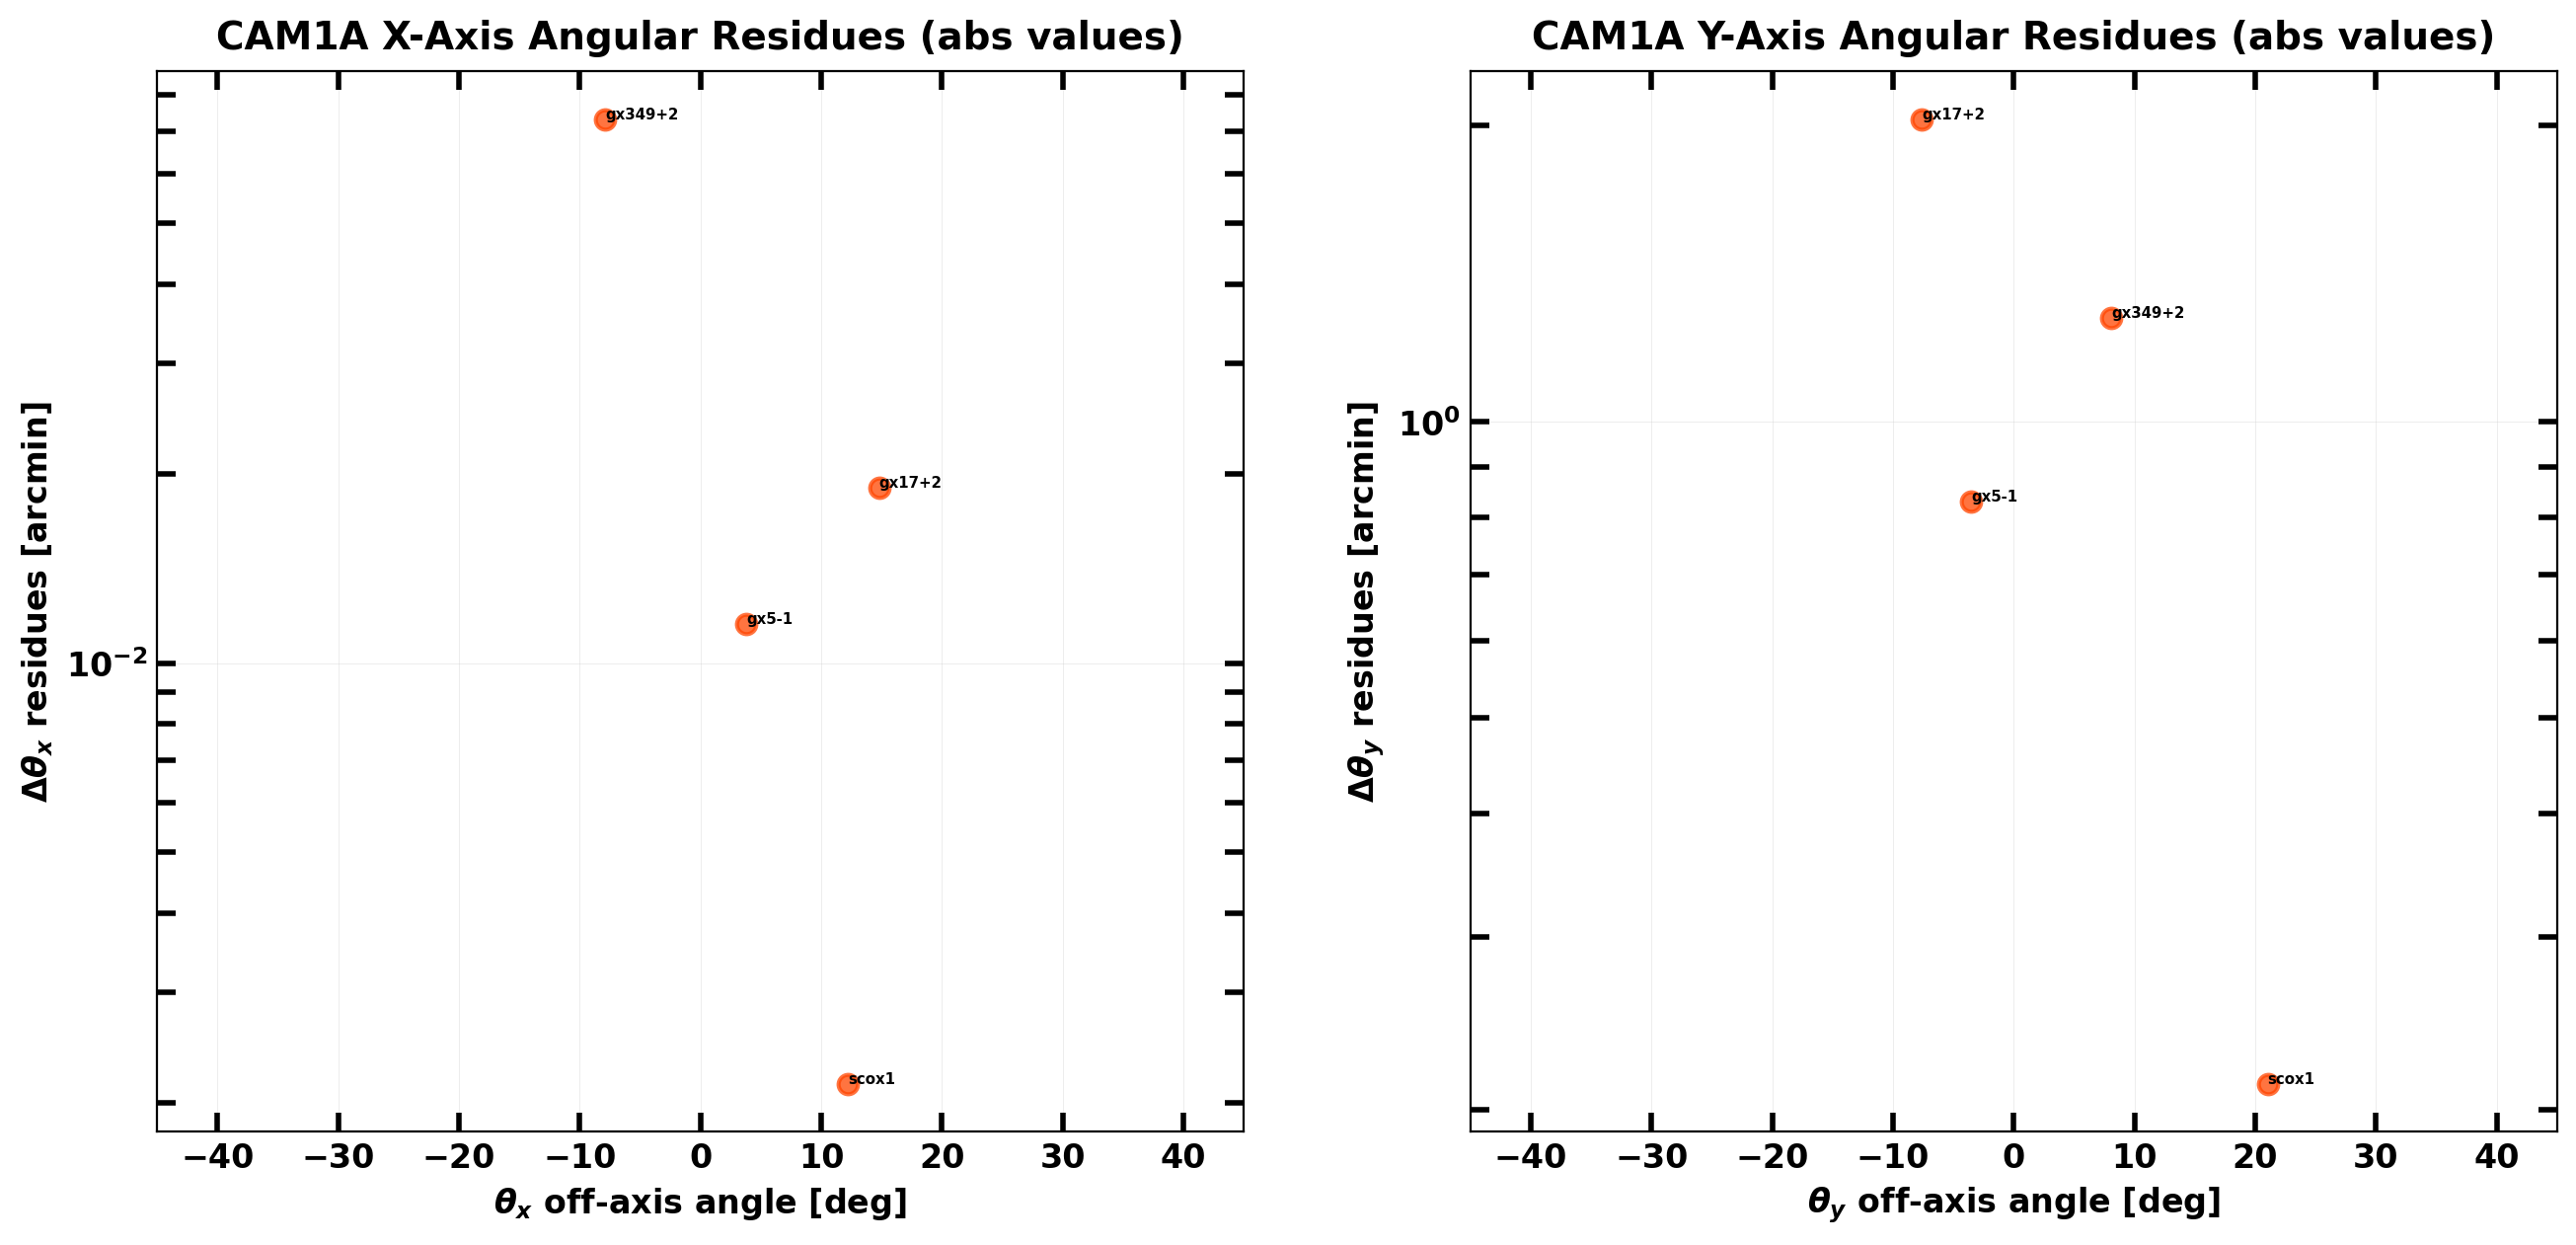

In [6]:
from typing import NamedTuple

from bloodmoon.mask import CodedMaskCamera
from bloodmoon.types import CoordEquatorial
from bloodmoon.coords import equatorial2shift, shift2angle

from darksun.types import Tag
from darksun.data import Log, DataLoader, CatalogueLoader

class CoordAngular(NamedTuple):
    """
    Local frame coded-mask camera angular coordinates.

    Args:
        theta_x (float): Angular coord along x-axis [deg]
        theta_y (float): Angular coord along y-axis [deg]
    """
    theta_x: float
    theta_y: float

def extract_catalogue_equatorial_coords(
    log: Log,
    catalogue: CatalogueLoader,
) -> tuple[tuple[str, CoordEquatorial]]:
    """
    """
    sources, ras, decs = [], [], []
    for s_id in log.log['ID']:
        if s_id in catalogue.DLdata['ID']:
            source = catalogue.DLdata[(catalogue.DLdata['ID'] == s_id)]
            sources.append(s_id)
            ras.append(source['RA'])
            decs.append(source['DEC'])
        else:
            print(f'Source {s_id.upper()} not in catalogue...')
            sources.append(s_id)
            ras.append(np.nan)
            decs.append(np.nan)
    return tuple(
        (name, CoordEquatorial(ra, dec)) for name, ra, dec in zip(sources, ras, decs)
    )

def extract_catalogue_angular_coords(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> tuple[tuple[str, CoordAngular]]:
    """
    """
    sources, thetas_x, thetas_y = [], [], []
    for s_id in log.log['ID']:
        if s_id in catalogue.DLdata['ID']:
            source = catalogue.DLdata[(catalogue.DLdata['ID'] == s_id)]
            sources.append(s_id)
            print(source['RA'], source['DEC'])
            sx, sy = equatorial2shift(sdl, camera, source['RA'][0], source['DEC'][0])
            thetas_x.append(shift2angle(camera, sx))
            thetas_y.append(shift2angle(camera, sy))
        else:
            print(f'Source {s_id.upper()} not in catalogue...')
            sources.append(s_id)
            thetas_x.append(np.nan)
            thetas_y.append(np.nan)
    return tuple(
        (name, CoordAngular(tx, ty)) for name, tx, ty in zip(sources, thetas_x, thetas_y)
    )


_, cat_theta = zip(
    *extract_catalogue_angular_coords(log=log_camA, catalogue=catalogueA, sdl=sdlA, camera=wfm)
)
cat_thetax, cat_thetay = zip(*cat_theta)

tagsx = tuple(
    Tag(n, r, t) for n, r, t in zip(
        log_camA.log['ID'], 60 * np.abs(np.array(log_camA.log['angle_x']) - np.array(cat_thetax)), cat_thetax,
    )
)
dmapx = ds.map4plot(
    arrs=60 * np.abs(np.array(log_camA.log['angle_x']) - np.array(cat_thetax)),
    title=f'{log_camA.name} X-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{x}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{x}}$ residues [arcmin]',
    x=np.array(cat_thetax),
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tagsx,
)
tagsy = tuple(
    Tag(n, r, t) for n, r, t in zip(
        log_camA.log['ID'], 60 * np.abs(np.array(log_camA.log['angle_y']) - np.array(cat_thetay)), cat_thetay,
    )
)
dmapy = ds.map4plot(
    arrs=60 * np.abs(np.array(log_camA.log['angle_y']) - np.array(cat_thetay)),
    title=f'{log_camA.name} Y-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{y}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{y}}$ residues [arcmin]',
    x=np.array(cat_thetay),
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tagsy,
)
ds.plot(
    (dmapx, dmapy),
    ncols=2,
    save_to=savefig_to(save_to, f'angularRes_{cam_a.upper()}' + '_newpathinmask') if save_things else None,
)

[244.97970581 244.97970581 244.97970581 244.97970581 244.97970581
 244.97970581 244.97970581 244.97970581 244.97970581 244.97970581] [-15.64009953 -15.64009953 -15.64009953 -15.64009953 -15.64009953
 -15.64009953 -15.64009953 -15.64009953 -15.64009953 -15.64009953]
[270.28479004 270.28479004 270.28479004 270.28479004 270.28479004
 270.28479004 270.28479004 270.28479004 270.28479004 270.28479004] [-25.07740021 -25.07740021 -25.07740021 -25.07740021 -25.07740021
 -25.07740021 -25.07740021 -25.07740021 -25.07740021 -25.07740021]
[256.43508911 256.43508911 256.43508911 256.43508911 256.43508911
 256.43508911 256.43508911 256.43508911 256.43508911 256.43508911] [-36.42129898 -36.42129898 -36.42129898 -36.42129898 -36.42129898
 -36.42129898 -36.42129898 -36.42129898 -36.42129898 -36.42129898]
[274.00698853 274.00698853 274.00698853 274.00698853 274.00698853
 274.00698853 274.00698853 274.00698853 274.00698853 274.00698853] [-14.03689957 -14.03689957 -14.03689957 -14.03689957 -14.03689957
 -1

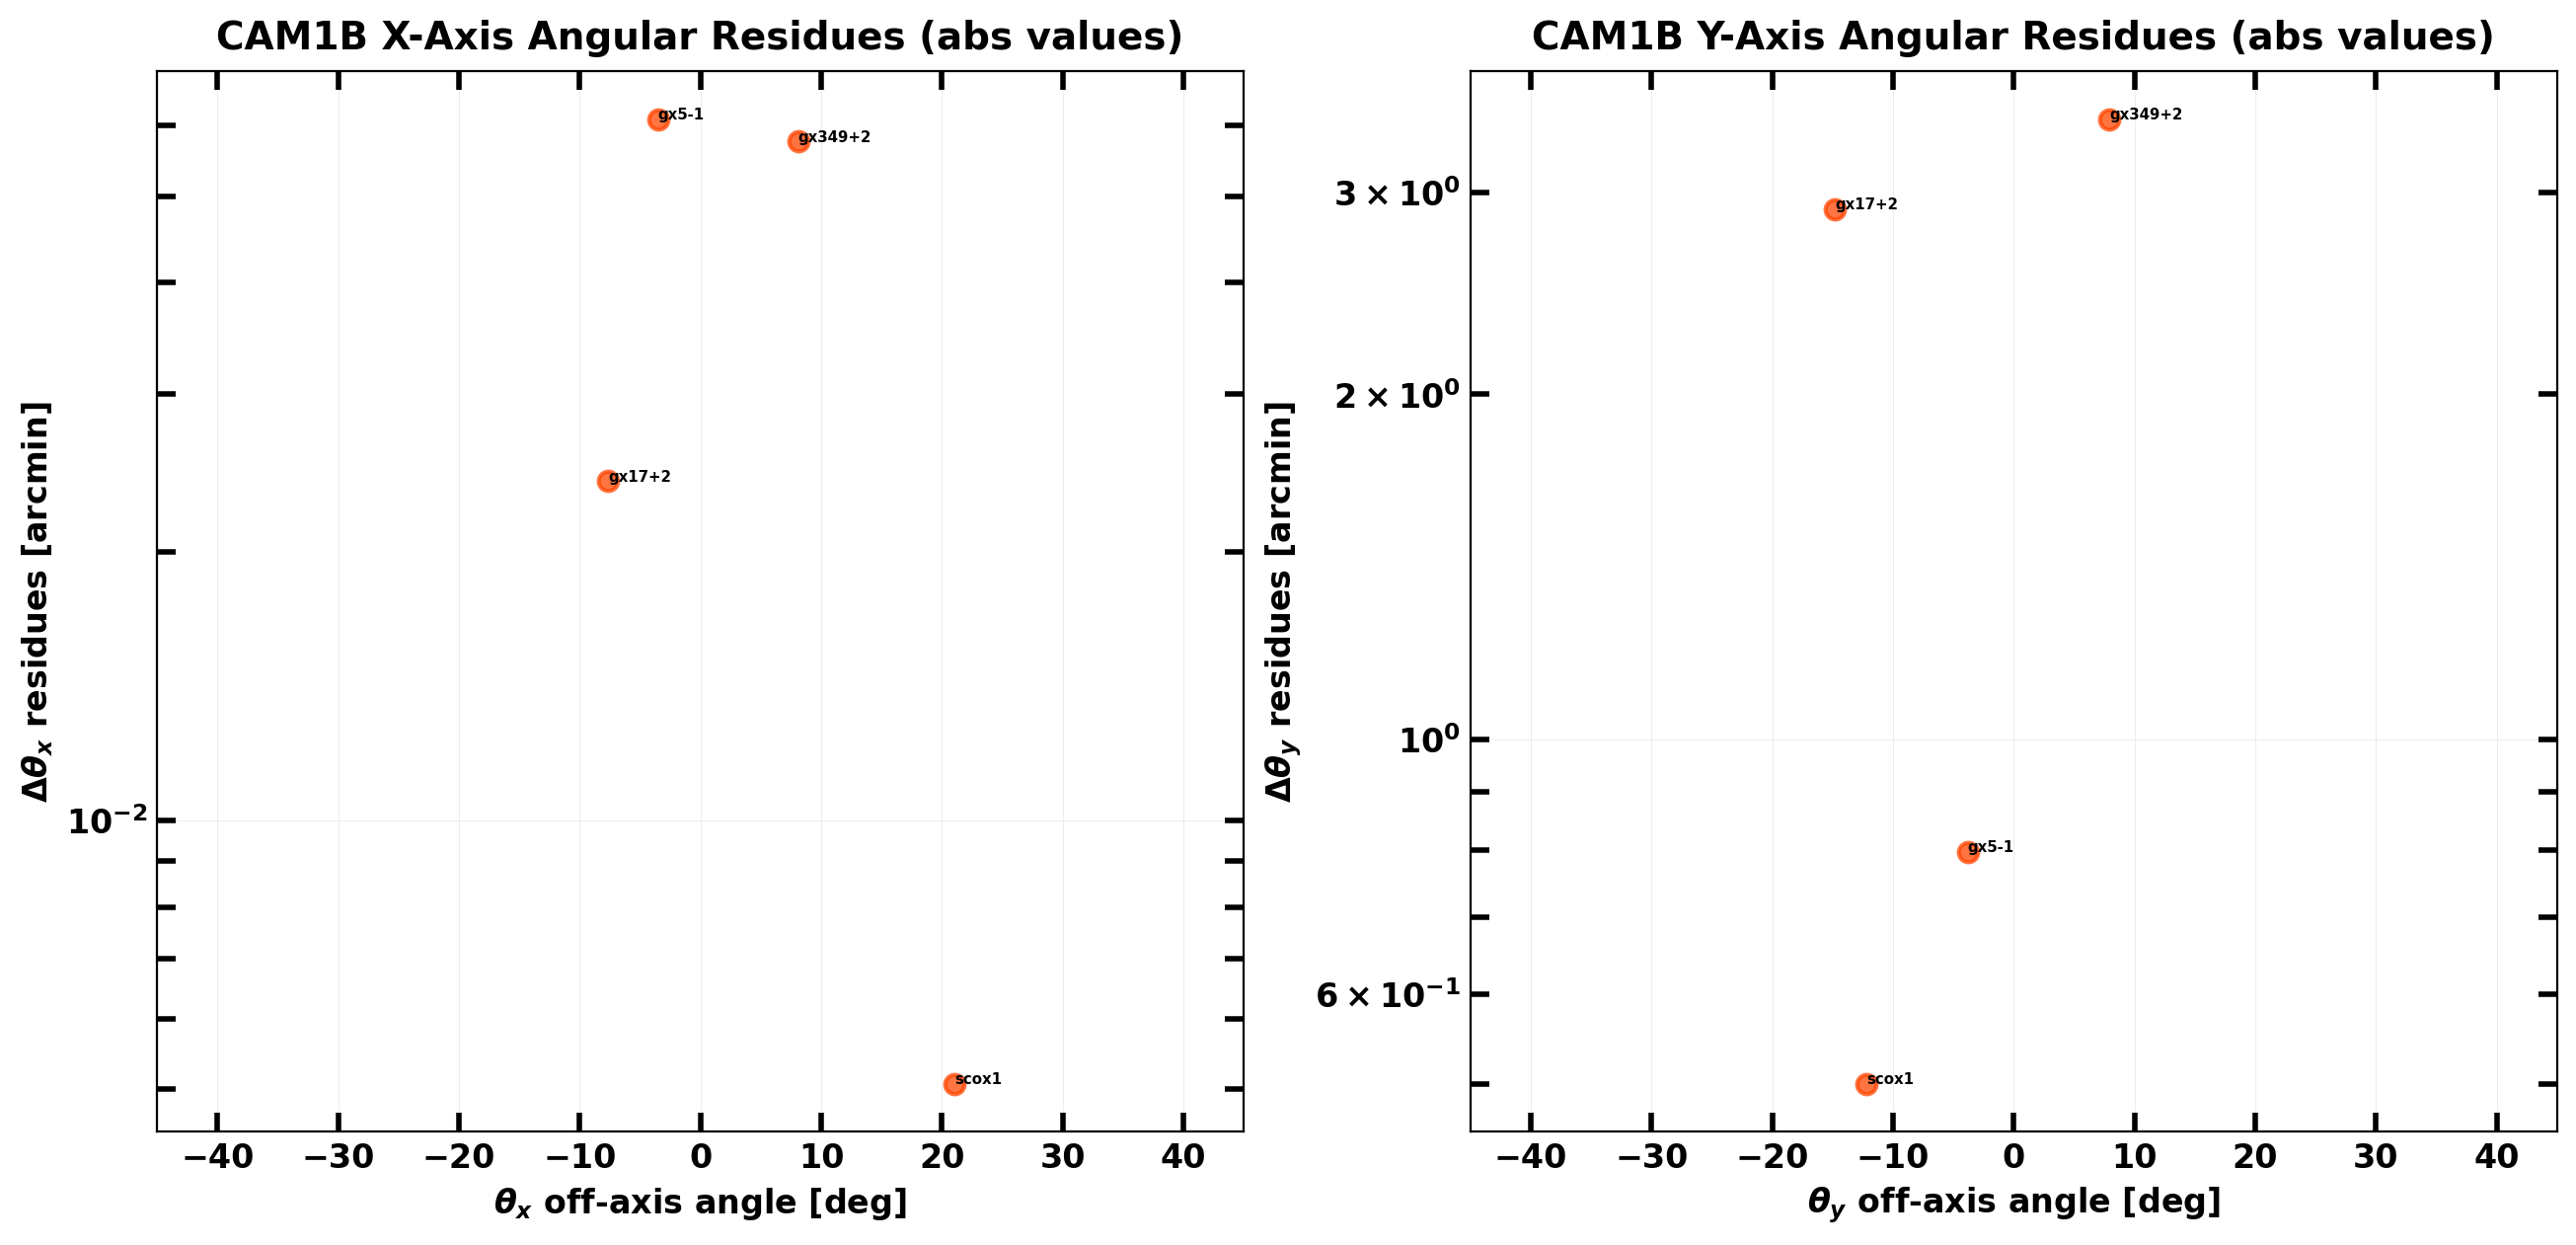

In [7]:
_, cat_theta_B = zip(
    *extract_catalogue_angular_coords(log=log_camB, catalogue=catalogueB, sdl=sdlB, camera=wfm)
)
cat_thetax_B, cat_thetay_B = zip(*cat_theta_B)

tagsx_B = tuple(
    Tag(n, r, t) for n, r, t in zip(
        log_camB.log['ID'], 60 * np.abs(np.array(log_camB.log['angle_x']) - np.array(cat_thetax_B)), cat_thetax_B,
    )
)
dmapx_B = ds.map4plot(
    arrs=60 * np.abs(np.array(log_camB.log['angle_x']) - np.array(cat_thetax_B)),
    title=f'{log_camB.name} X-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{x}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{x}}$ residues [arcmin]',
    x=np.array(cat_thetax_B),
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tagsx_B,
)
tagsy_B = tuple(
    Tag(n, r, t) for n, r, t in zip(
        log_camB.log['ID'], 60 * np.abs(np.array(log_camB.log['angle_y']) - np.array(cat_thetay_B)), cat_thetay_B,
    )
)
dmapy_B = ds.map4plot(
    arrs=60 * np.abs(np.array(log_camB.log['angle_y']) - np.array(cat_thetay_B)),
    title=f'{log_camB.name} Y-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{y}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{y}}$ residues [arcmin]',
    x=np.array(cat_thetay_B),
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tagsy_B,
)
ds.plot(
    (dmapx_B, dmapy_B),
    ncols=2,
    save_to=savefig_to(save_to, f'angularRes_{cam_b.upper()}' + '_newpathinmask') if save_things else None,
)

In [8]:
from typing import Any
from numpy.typing import NDArray
from pandas import DataFrame

def dict2df(data: dict[str, dict[str, Any]]) -> DataFrame:
    """
    Converts input data in a Pandas dataframe.

    Args:
        data (dict): Input data.
    
    Returns:
        output (DataFrame): Output dataframe.
    """
    df = DataFrame({
        (cam, param): values
        for cam, cam_data in data.items() 
        for param, values in cam_data.items()
    })
    return df


def get_angularcoords_residues(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> tuple[NDArray, NDArray]:
    """
    """
    _, cat_theta = zip(
        *extract_catalogue_angular_coords(log=log, catalogue=catalogue, sdl=sdl, camera=camera)
    )
    cat_thetax, cat_thetay = zip(*cat_theta)
    resx = 60 * np.abs(np.array(log.log['angle_x']) - np.array(cat_thetax))
    resy = 60 * np.abs(np.array(log.log['angle_y']) - np.array(cat_thetay))
    return resx, resy

resxA, resyA = get_angularcoords_residues(log=log_camA, catalogue=catalogueA, sdl=sdlA, camera=wfm)
resxB, resyB = get_angularcoords_residues(log=log_camB, catalogue=catalogueB, sdl=sdlB, camera=wfm)

dmapA = {
    log_camA.name: {
        'ID': log_camA.log['ID'],
        'SNR': log_camA.log['snr'],
        'DthetaX [arcmin]': resxA,
        'DthetaY [arcmin]': resyA,
    },
}

dmapB = {
    log_camB.name: {
        'ID': log_camB.log['ID'],
        'SNR': log_camB.log['snr'],
        'DthetaX [arcmin]': resxB,
        'DthetaY [arcmin]': resyB,
    },
}

[244.97970581 244.97970581 244.97970581 244.97970581 244.97970581
 244.97970581 244.97970581 244.97970581 244.97970581 244.97970581] [-15.64009953 -15.64009953 -15.64009953 -15.64009953 -15.64009953
 -15.64009953 -15.64009953 -15.64009953 -15.64009953 -15.64009953]
[270.28479004 270.28479004 270.28479004 270.28479004 270.28479004
 270.28479004 270.28479004 270.28479004 270.28479004 270.28479004] [-25.07740021 -25.07740021 -25.07740021 -25.07740021 -25.07740021
 -25.07740021 -25.07740021 -25.07740021 -25.07740021 -25.07740021]
[256.43508911 256.43508911 256.43508911 256.43508911 256.43508911
 256.43508911 256.43508911 256.43508911 256.43508911 256.43508911] [-36.42129898 -36.42129898 -36.42129898 -36.42129898 -36.42129898
 -36.42129898 -36.42129898 -36.42129898 -36.42129898 -36.42129898]
[274.00698853 274.00698853 274.00698853 274.00698853 274.00698853
 274.00698853 274.00698853 274.00698853 274.00698853 274.00698853] [-14.03689957 -14.03689957 -14.03689957 -14.03689957 -14.03689957
 -1

In [9]:
dict2df(dmapA)

CAM1A                                              
        ID         SNR DthetaX [arcmin] DthetaY [arcmin]
0    scox1  807.018039         0.002145         0.212658
1    gx5-1   78.392412         0.011533         0.830498
2  gx349+2   59.630525         0.073207         1.276640
3   gx17+2   50.889482         0.019007         2.031236

In [10]:
dict2df(dmapB)

CAM1B                                              
        ID         SNR DthetaX [arcmin] DthetaY [arcmin]
0    scox1  758.580526         0.005073         0.500962
1    gx5-1   86.301188         0.060993         0.798191
2  gx349+2   56.548893         0.057586         3.474493
3   gx17+2   52.634440         0.023990         2.901563

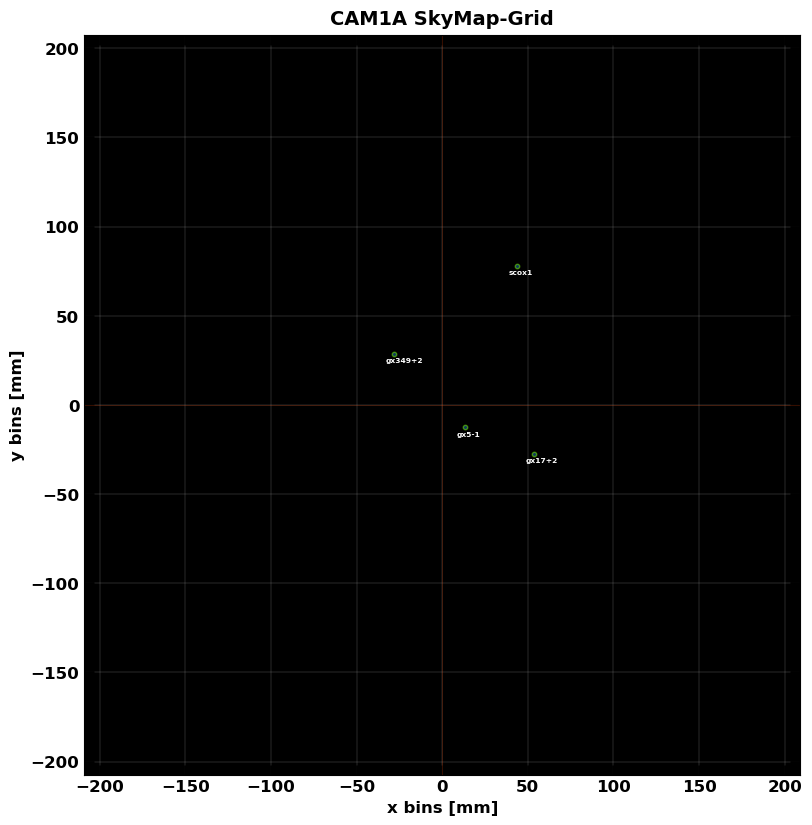

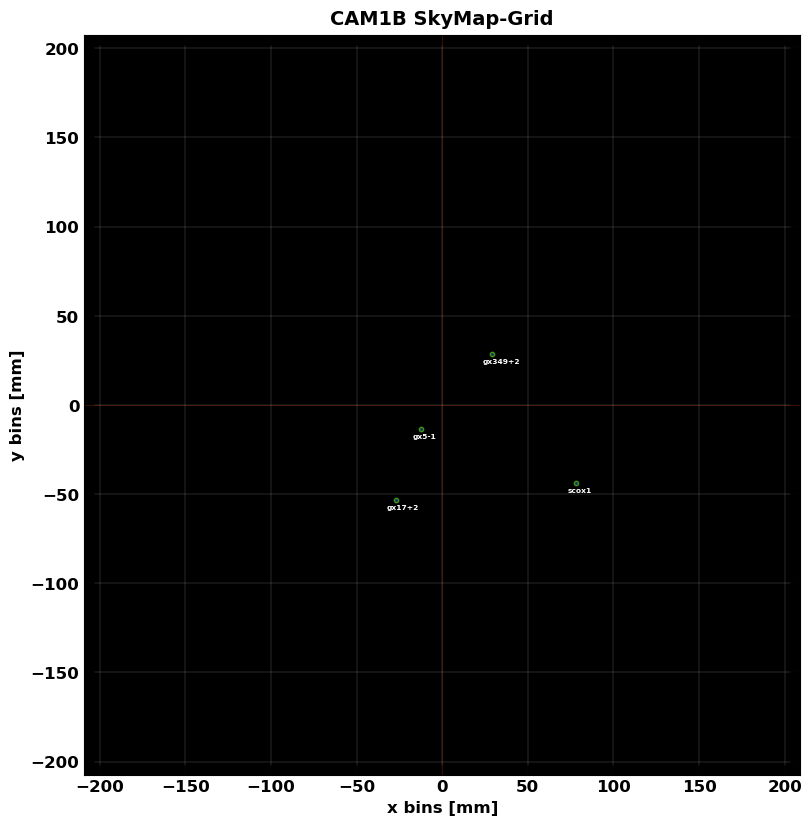

In [11]:
ds.skyfield_map(log_camA, wfm) # save_to=is_img(f'skymap_grid_{log_camA.name}'))
ds.skyfield_map(log_camB, wfm) # save_to=is_img(f'skymap_grid_{log_camB.name}'))

In [12]:
def reconstruction_plot(
    true_sky: NDArray,
    log: Log,
    crp: tuple[int, int],
    camera: CodedMaskCamera,
    *,
    vignetting: bool = True,
    psfy: bool = True,
    savepath: Any = None,
) -> None:
    """
    Displays the IROS reconstruction effect wrt the original decoded sky.

    Specifically, it shows:
        - IROS reconstructed source slices wrt the true sky
        - source slices residues
        - source profiles residues heatmap

    Args:
        true_sky (NDArray):
            True observed decoded sky.
        log (Log):
            Reconstructed sources database.
        crp (tuple[int, int]):
            Size of the cropping along (y, x).
        camera (CodedMaskCamera):
            CodedMaskCamera instance used for imaging and reconstruction.
        vignetting (bool, optional (default=`True`)):
            Simulates vignetting effects.
        psfy (bool, optional (default=`True`)):
            Simulates detector reconstruction effects.
    
    ## Notes:
        - A copy of `true_sky` is used to avoid memory overwrite.
    """
    true_sky_ = true_sky.copy()
    UPX, UPY = camera.upscale_f

    for source, sx, sy, f, x, y in zip(
        log.log['ID'],
        log.log['shift_x'],
        log.log['shift_y'],
        log.log['fluence'],
        log.log['x'],
        log.log['y'],
    ):
        POS = (y, x)

        # simulate source
        modeled = model_sky(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            fluence=f,
            vignetting=vignetting,
            psfy=psfy,
        ).astype(np.int32)

        # plot IROS vs True skies slices (profiles and residues)
        ds.slices_plot(
            sky=(true_sky_, modeled),
            pos=POS,
            crp=crp,
            source=source,
            labels=('True', 'IROS'),
            cameraID=log.name,
            save_to=(
                savepath(f'{source.upper()}_profile') if savepath is not None else None
            ),
        )
        ds.slices_plot(
            sky=true_sky_ - modeled,
            pos=POS,
            crp=crp,
            source=source,
            ylabel='residues [ph]',
            cameraID=log.name,
            save_to=(
                savepath(f'{source.upper()}_profile_res') if savepath is not None else None
            ),
        )

        # plot IROS vs True residues heatmaps
        CUT = (
            int(camera.specs['slit_deltay'] * UPY / camera.specs['mask_deltay']) + 1,
            int(camera.specs['slit_deltax'] * UPX / camera.specs['mask_deltax']) + 1,
        )
        F_UPY, F_UPX = 2, 5

        true_crp, modeled_crp = map(
            lambda x: ds.crop(x, pos=POS, crp=CUT, strict=False),
            (true_sky_, modeled),
        )
        vlim = np.max(np.abs(true_crp - modeled_crp))
        ds.image_plot(
            dmaps=ds.map4image(
                img=ds.upscale(true_crp - modeled_crp, F_UPY, F_UPX) * np.prod((F_UPY, F_UPX)),
                title=f'True - IROS Residues {log.name}',
                cbarlabel='counts',
                img_kwargs={
                    'vmin': -vlim,
                    'vmax': vlim,
                    'cmap': 'bwr',
                    'extent': (-CUT[1] * F_UPX, CUT[1] * F_UPX, -CUT[0] * F_UPY, CUT[0] * F_UPY),
                },
            ),
            save_to=(
                savepath(f'{source.upper()}_res_HM') if savepath is not None else None
            ),
        )

        # remove source from True sky
        true_sky_ -= modeled

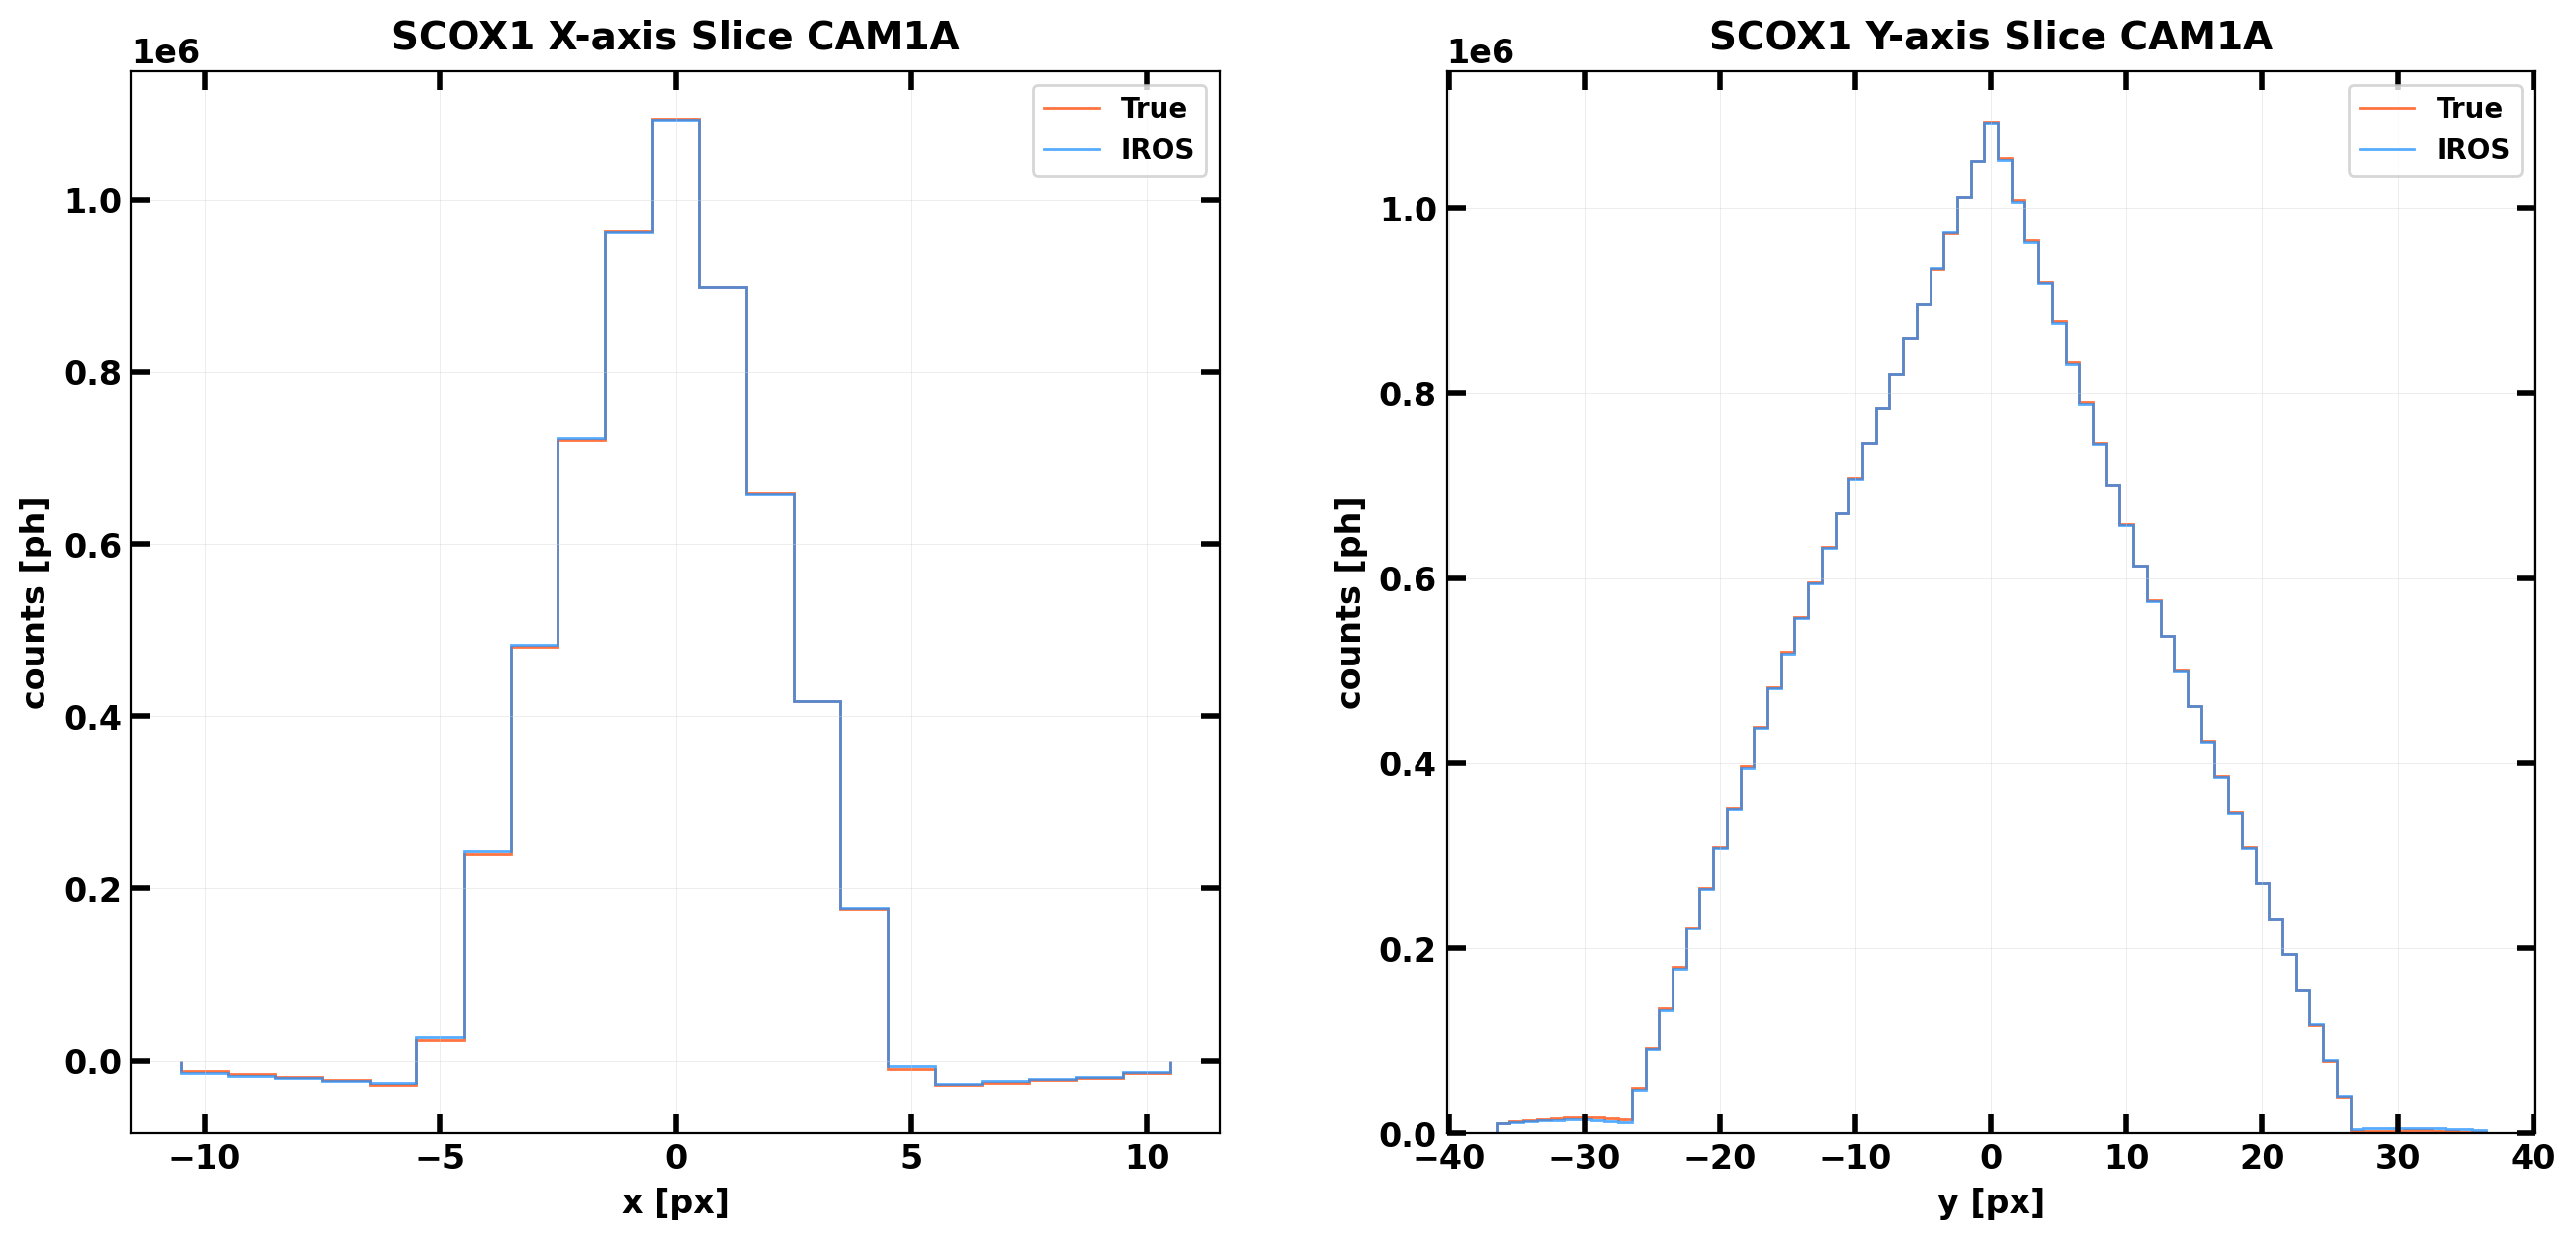

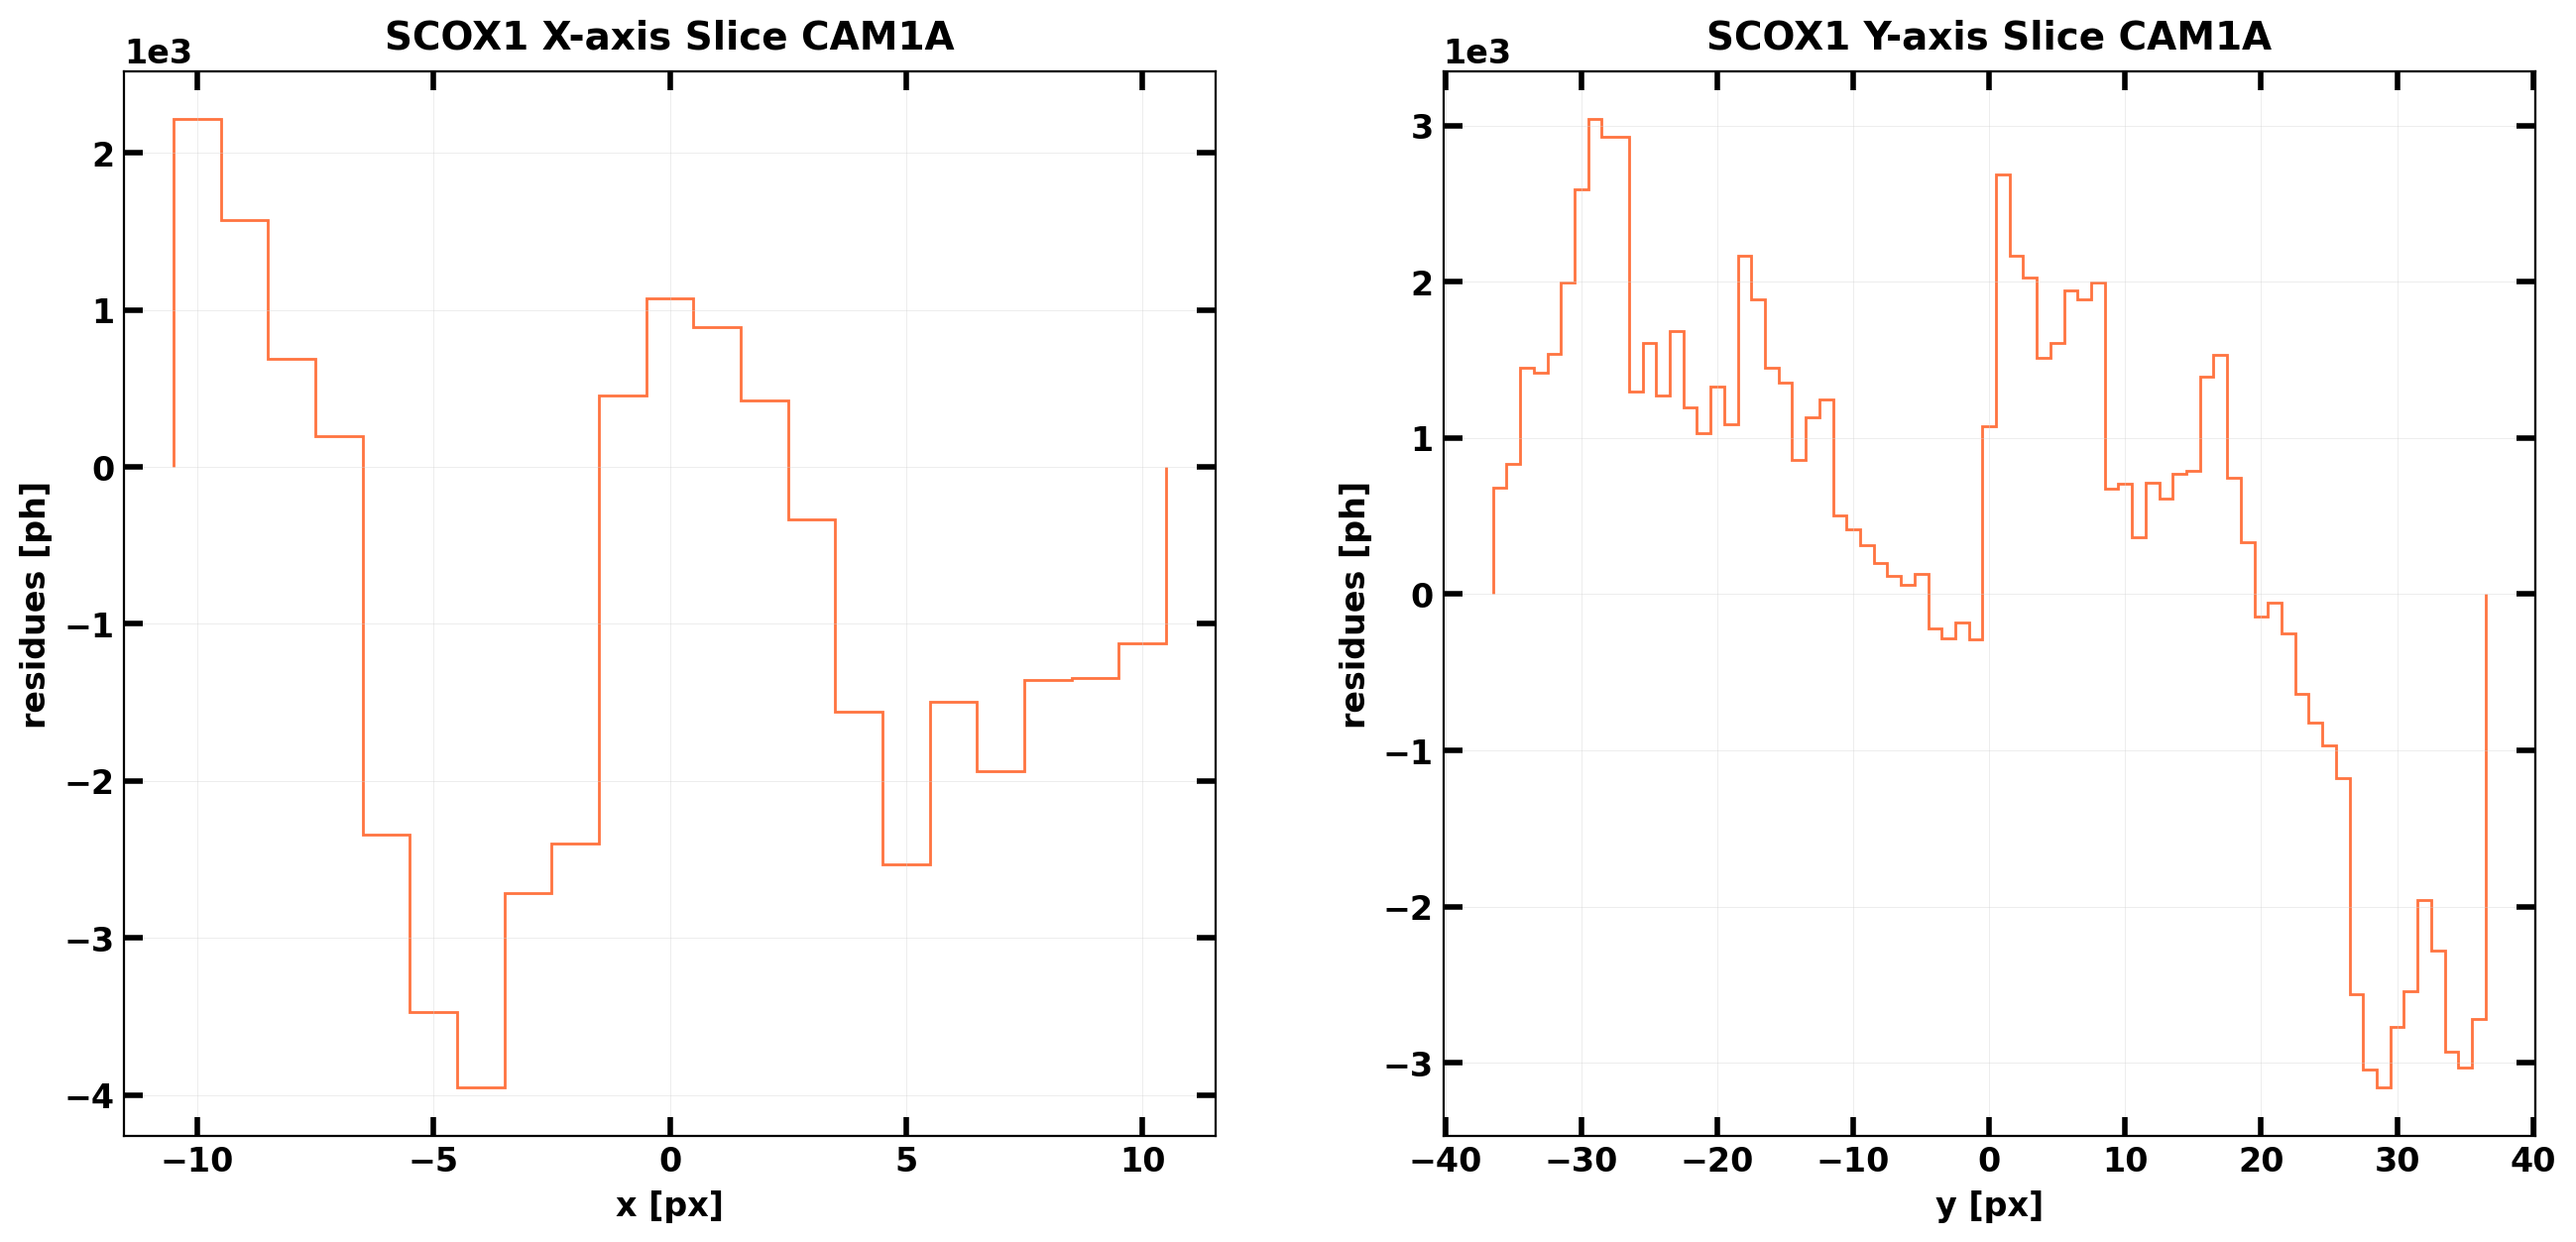

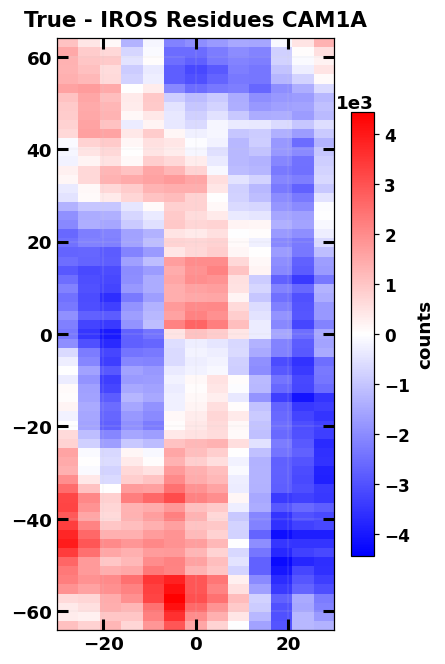

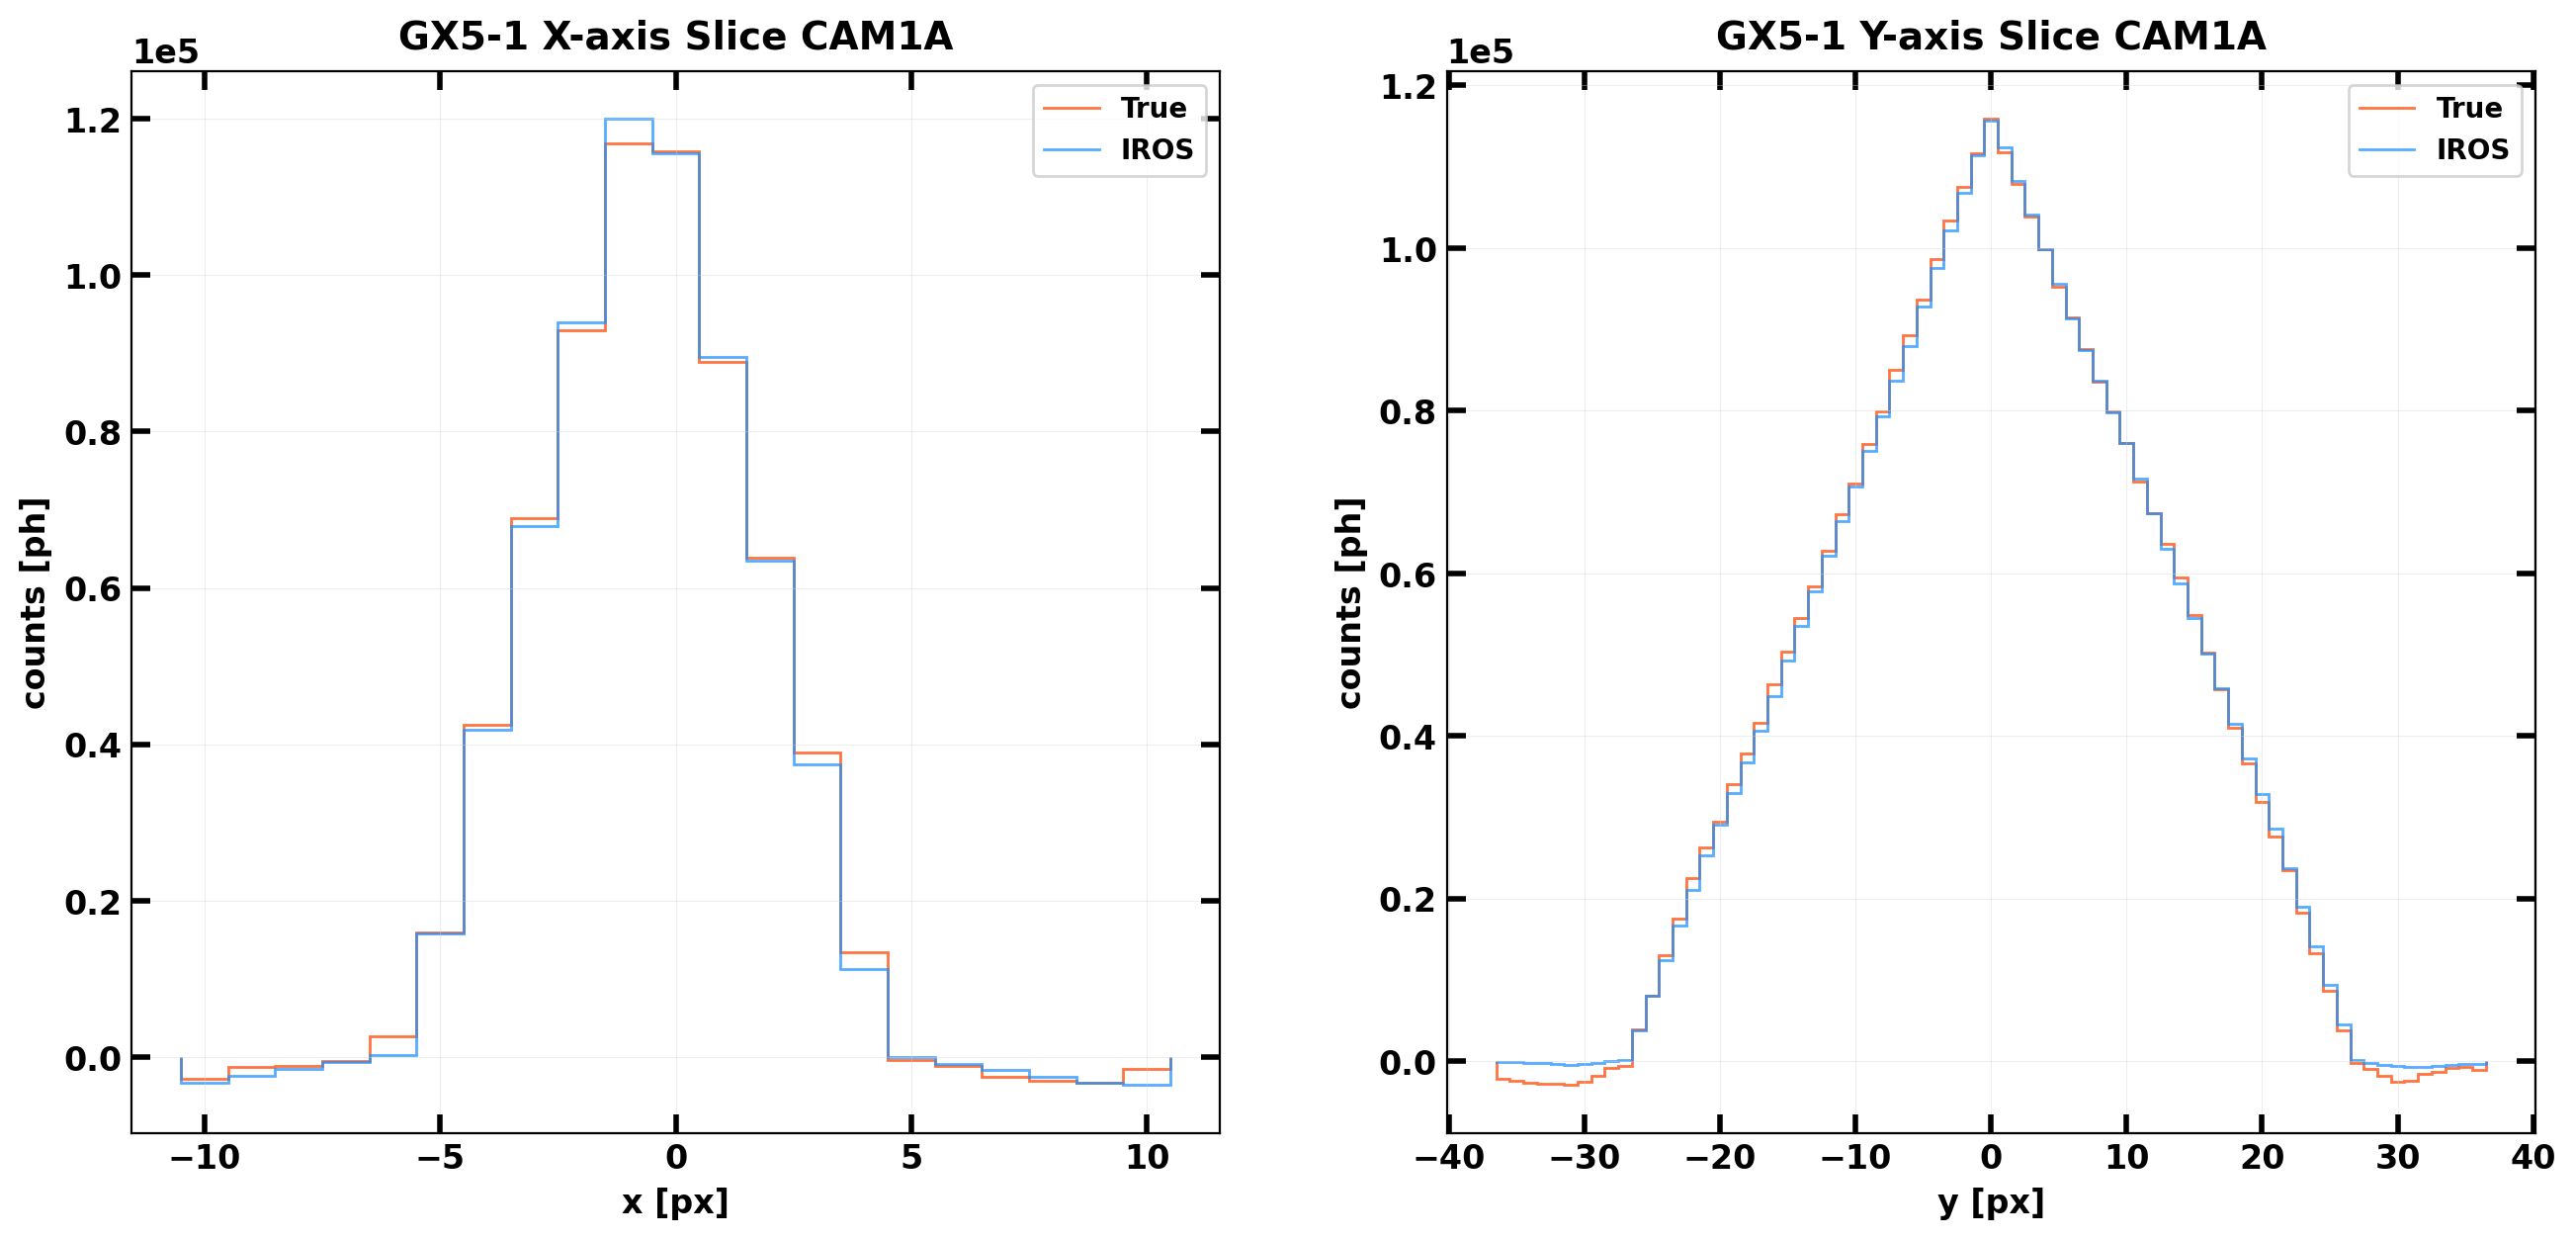

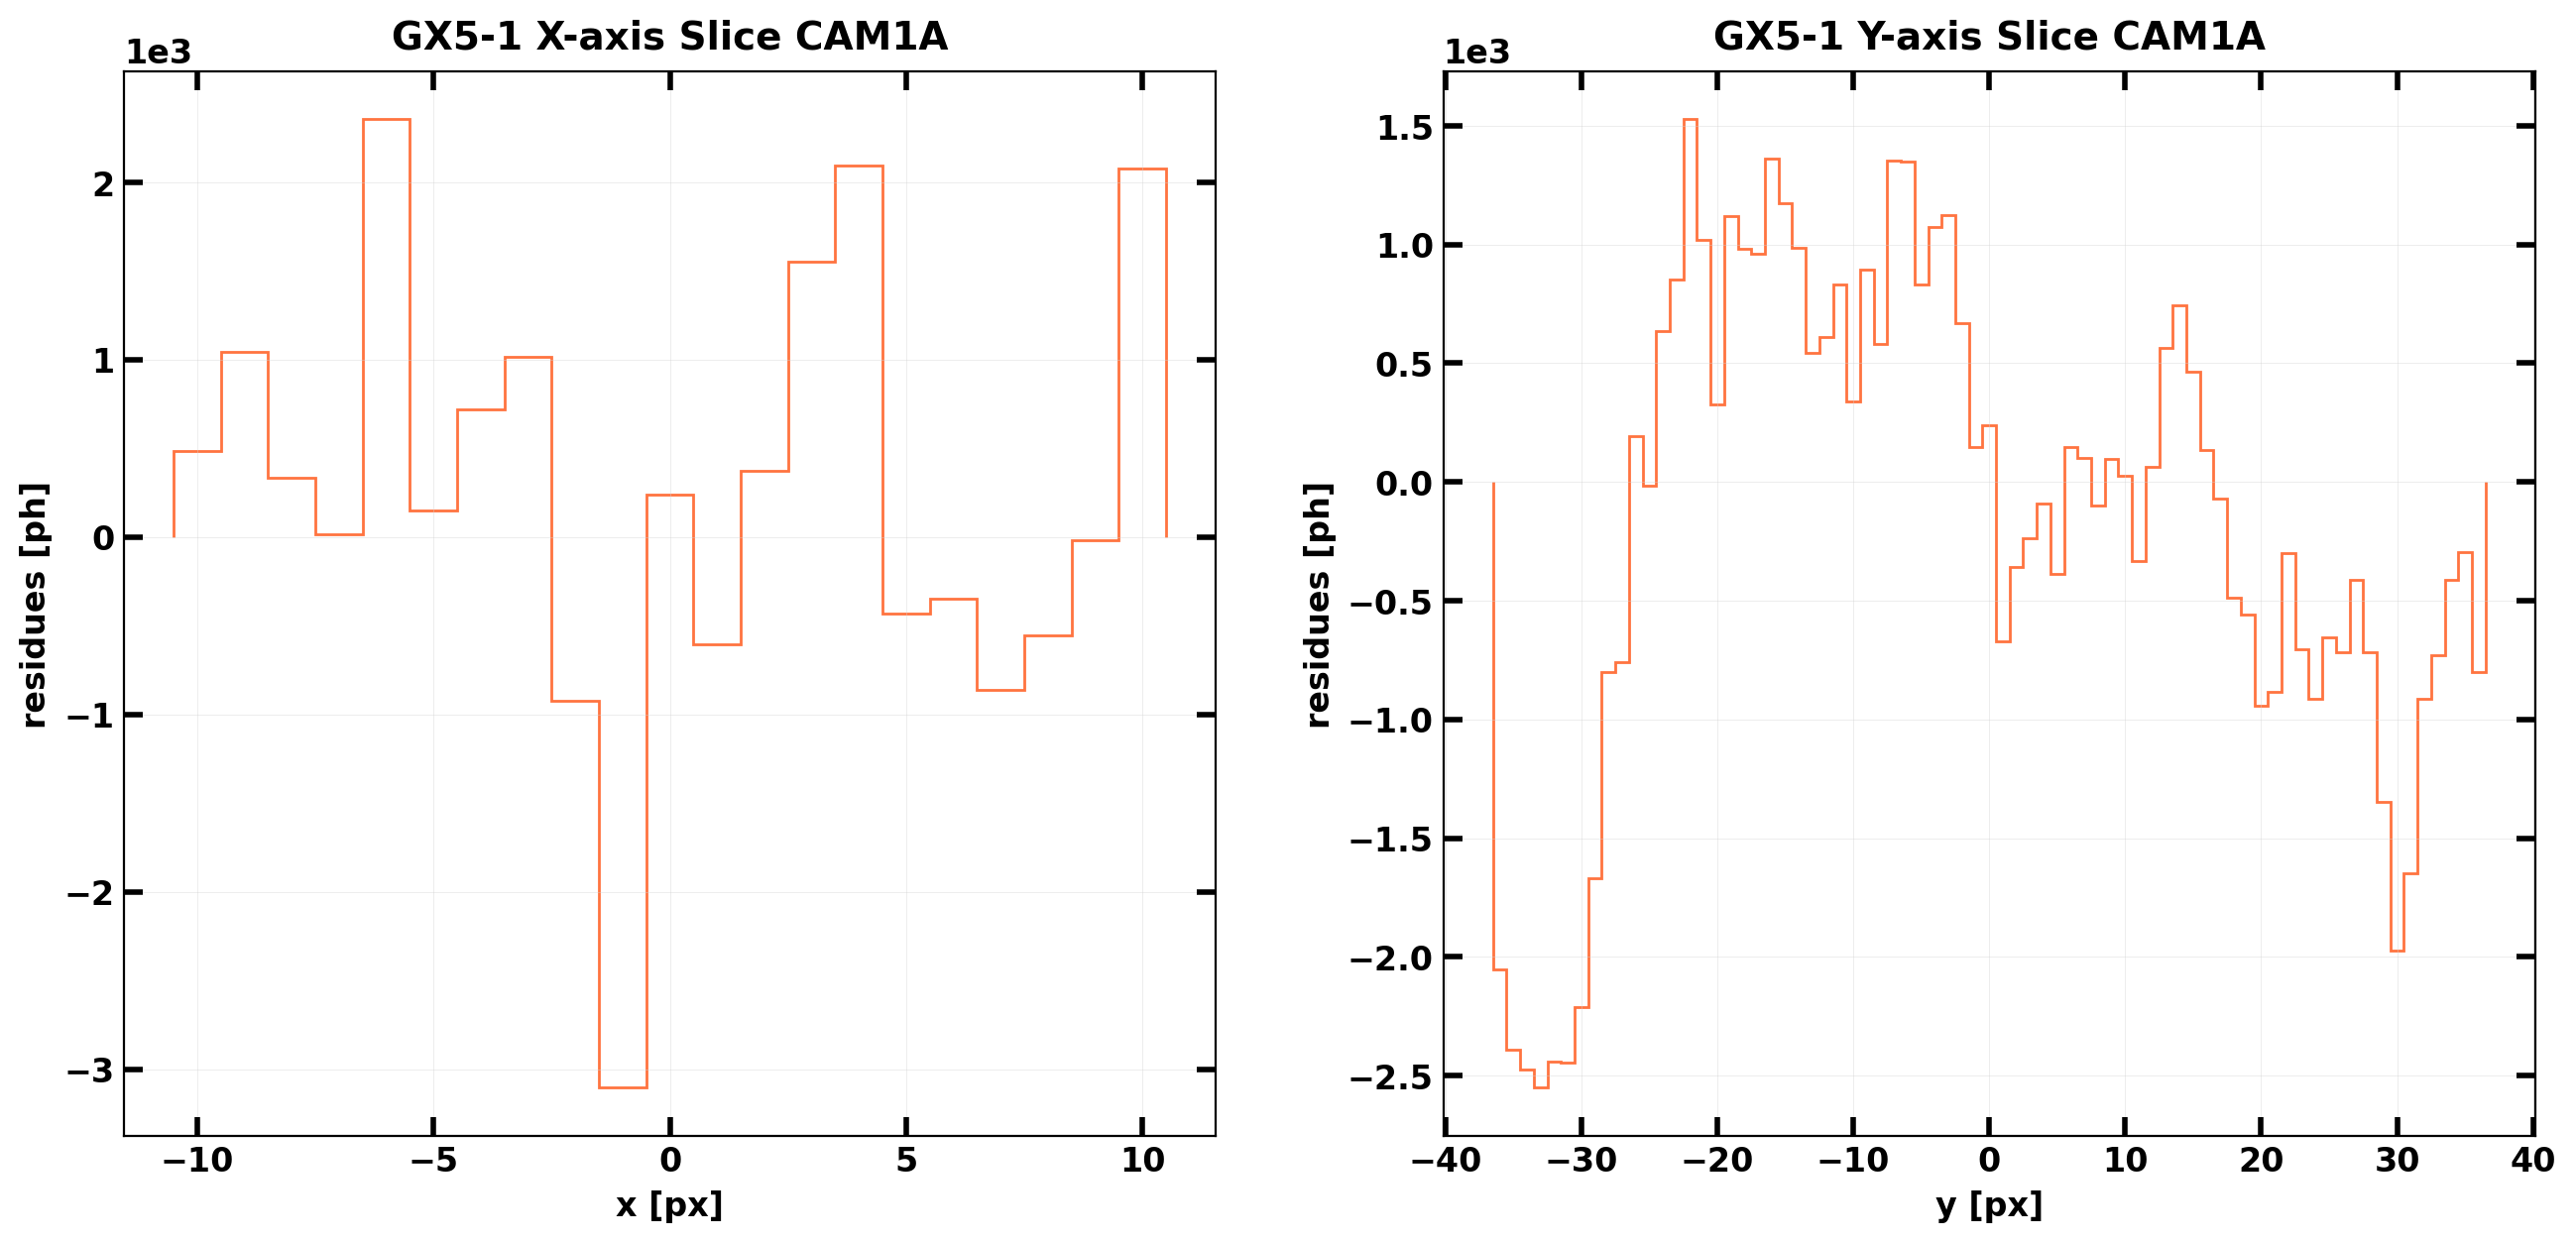

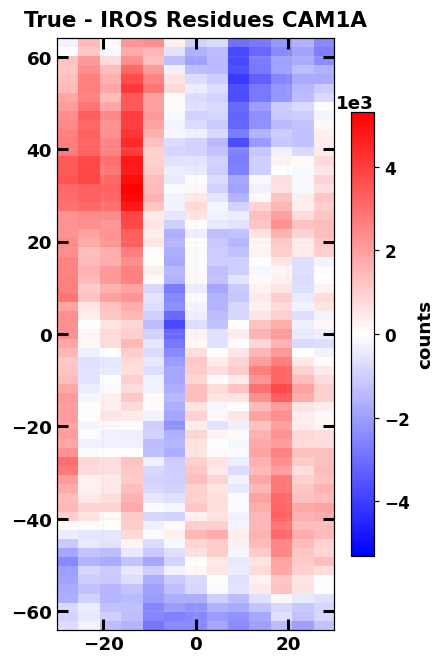

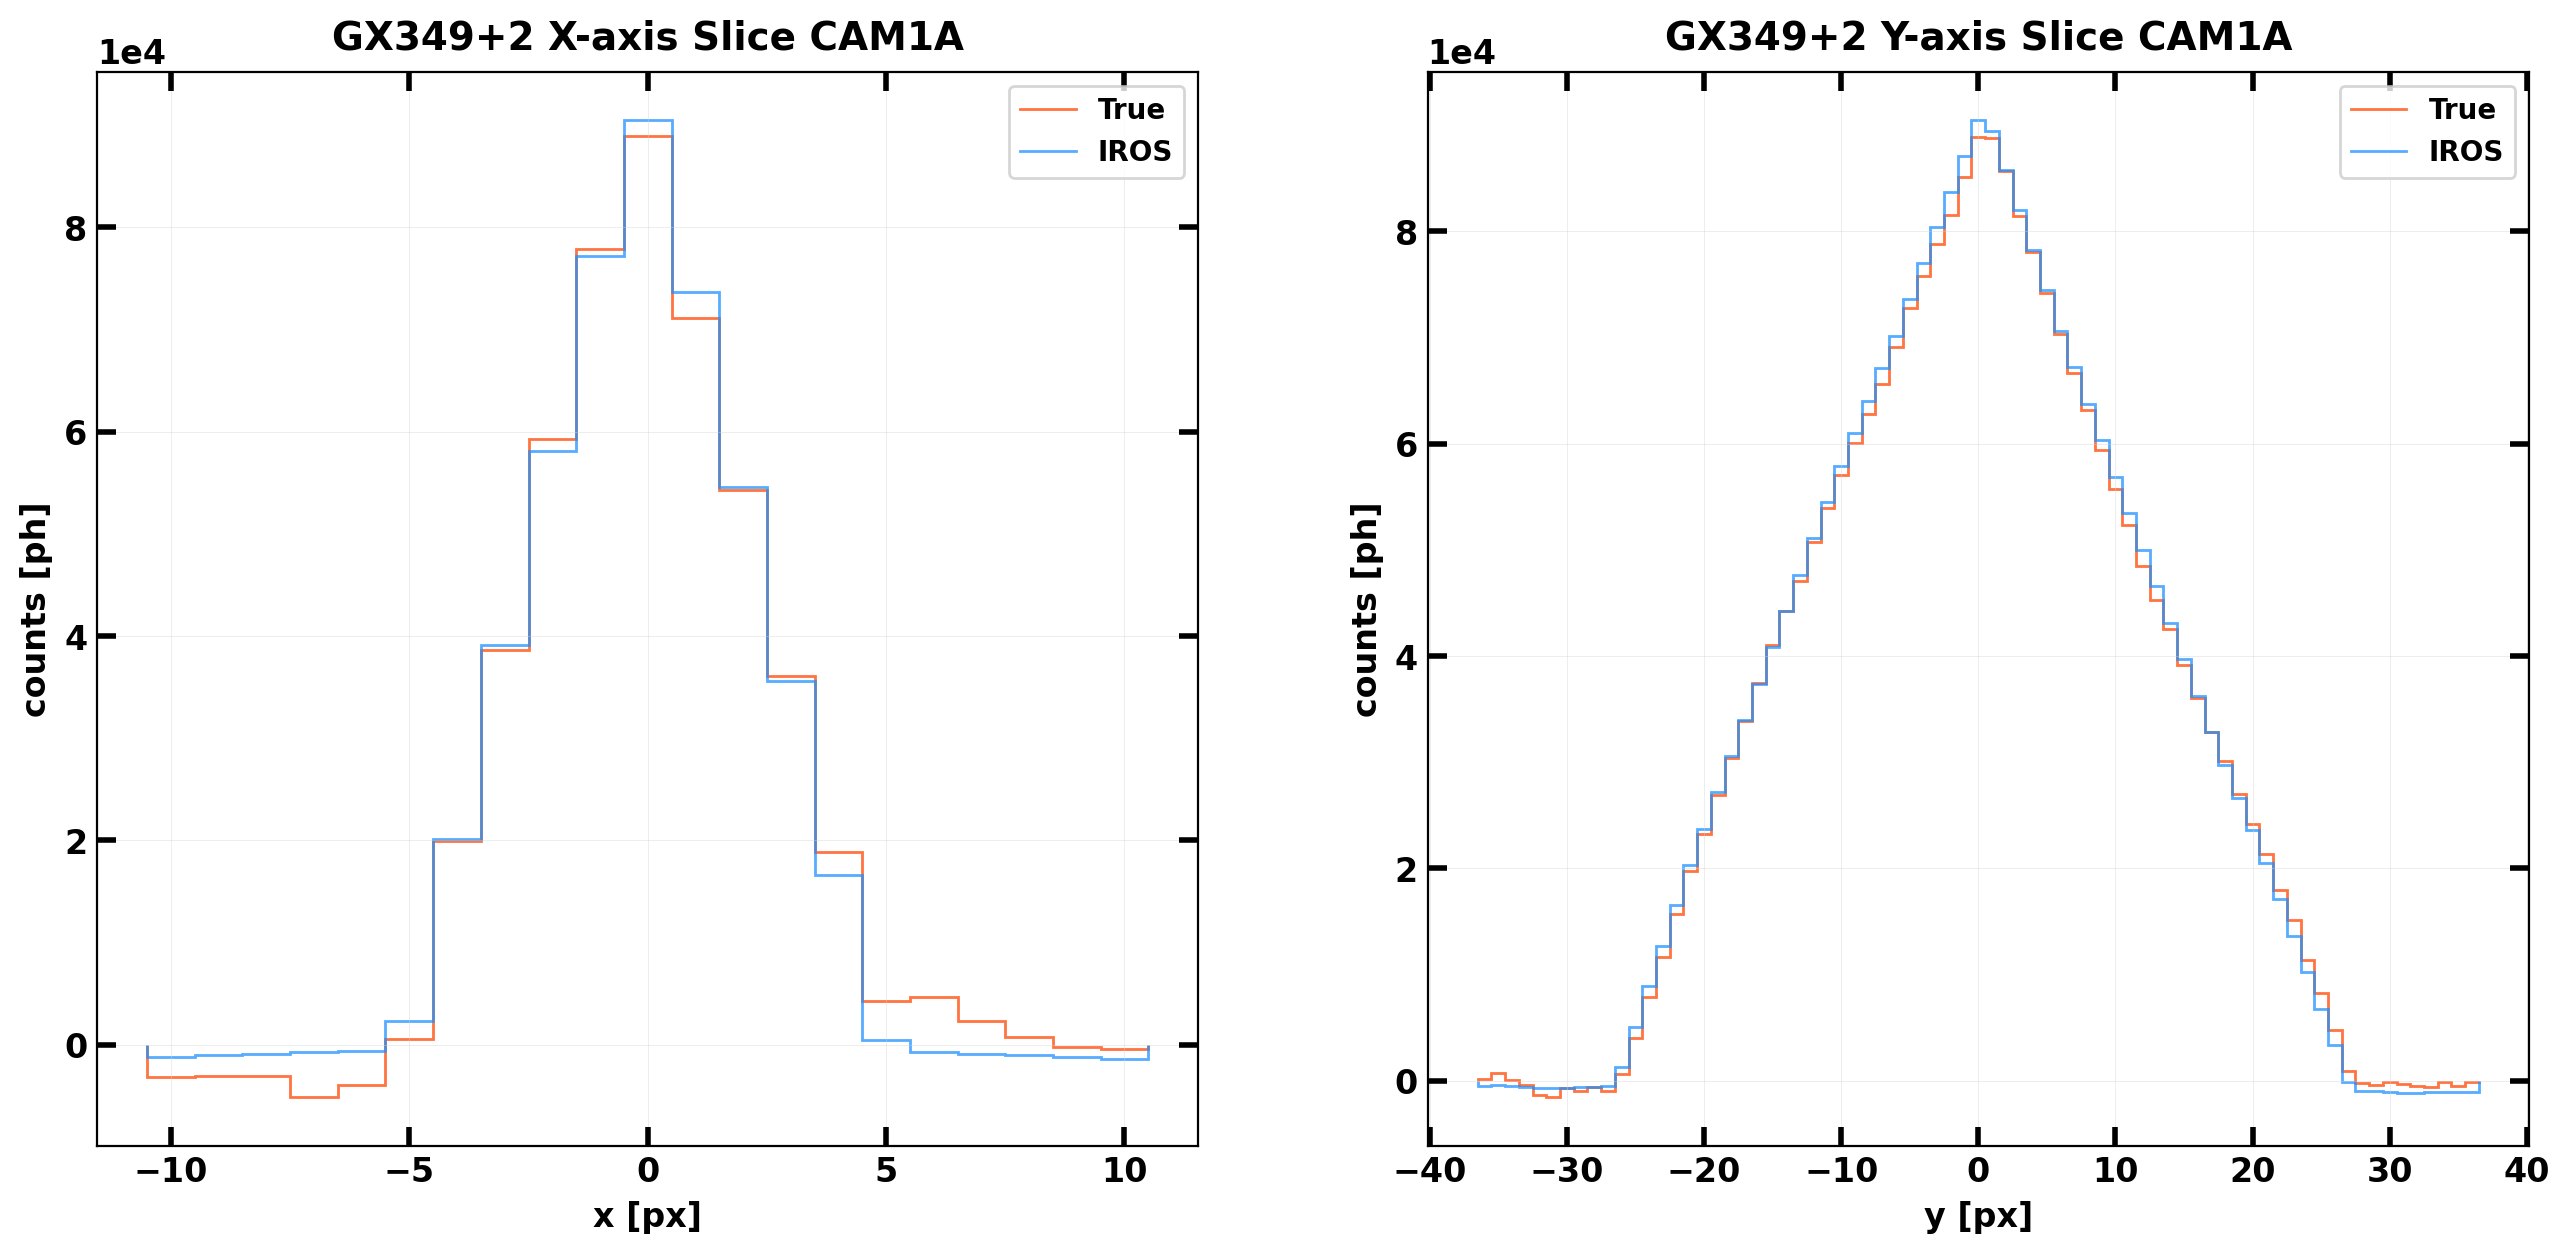

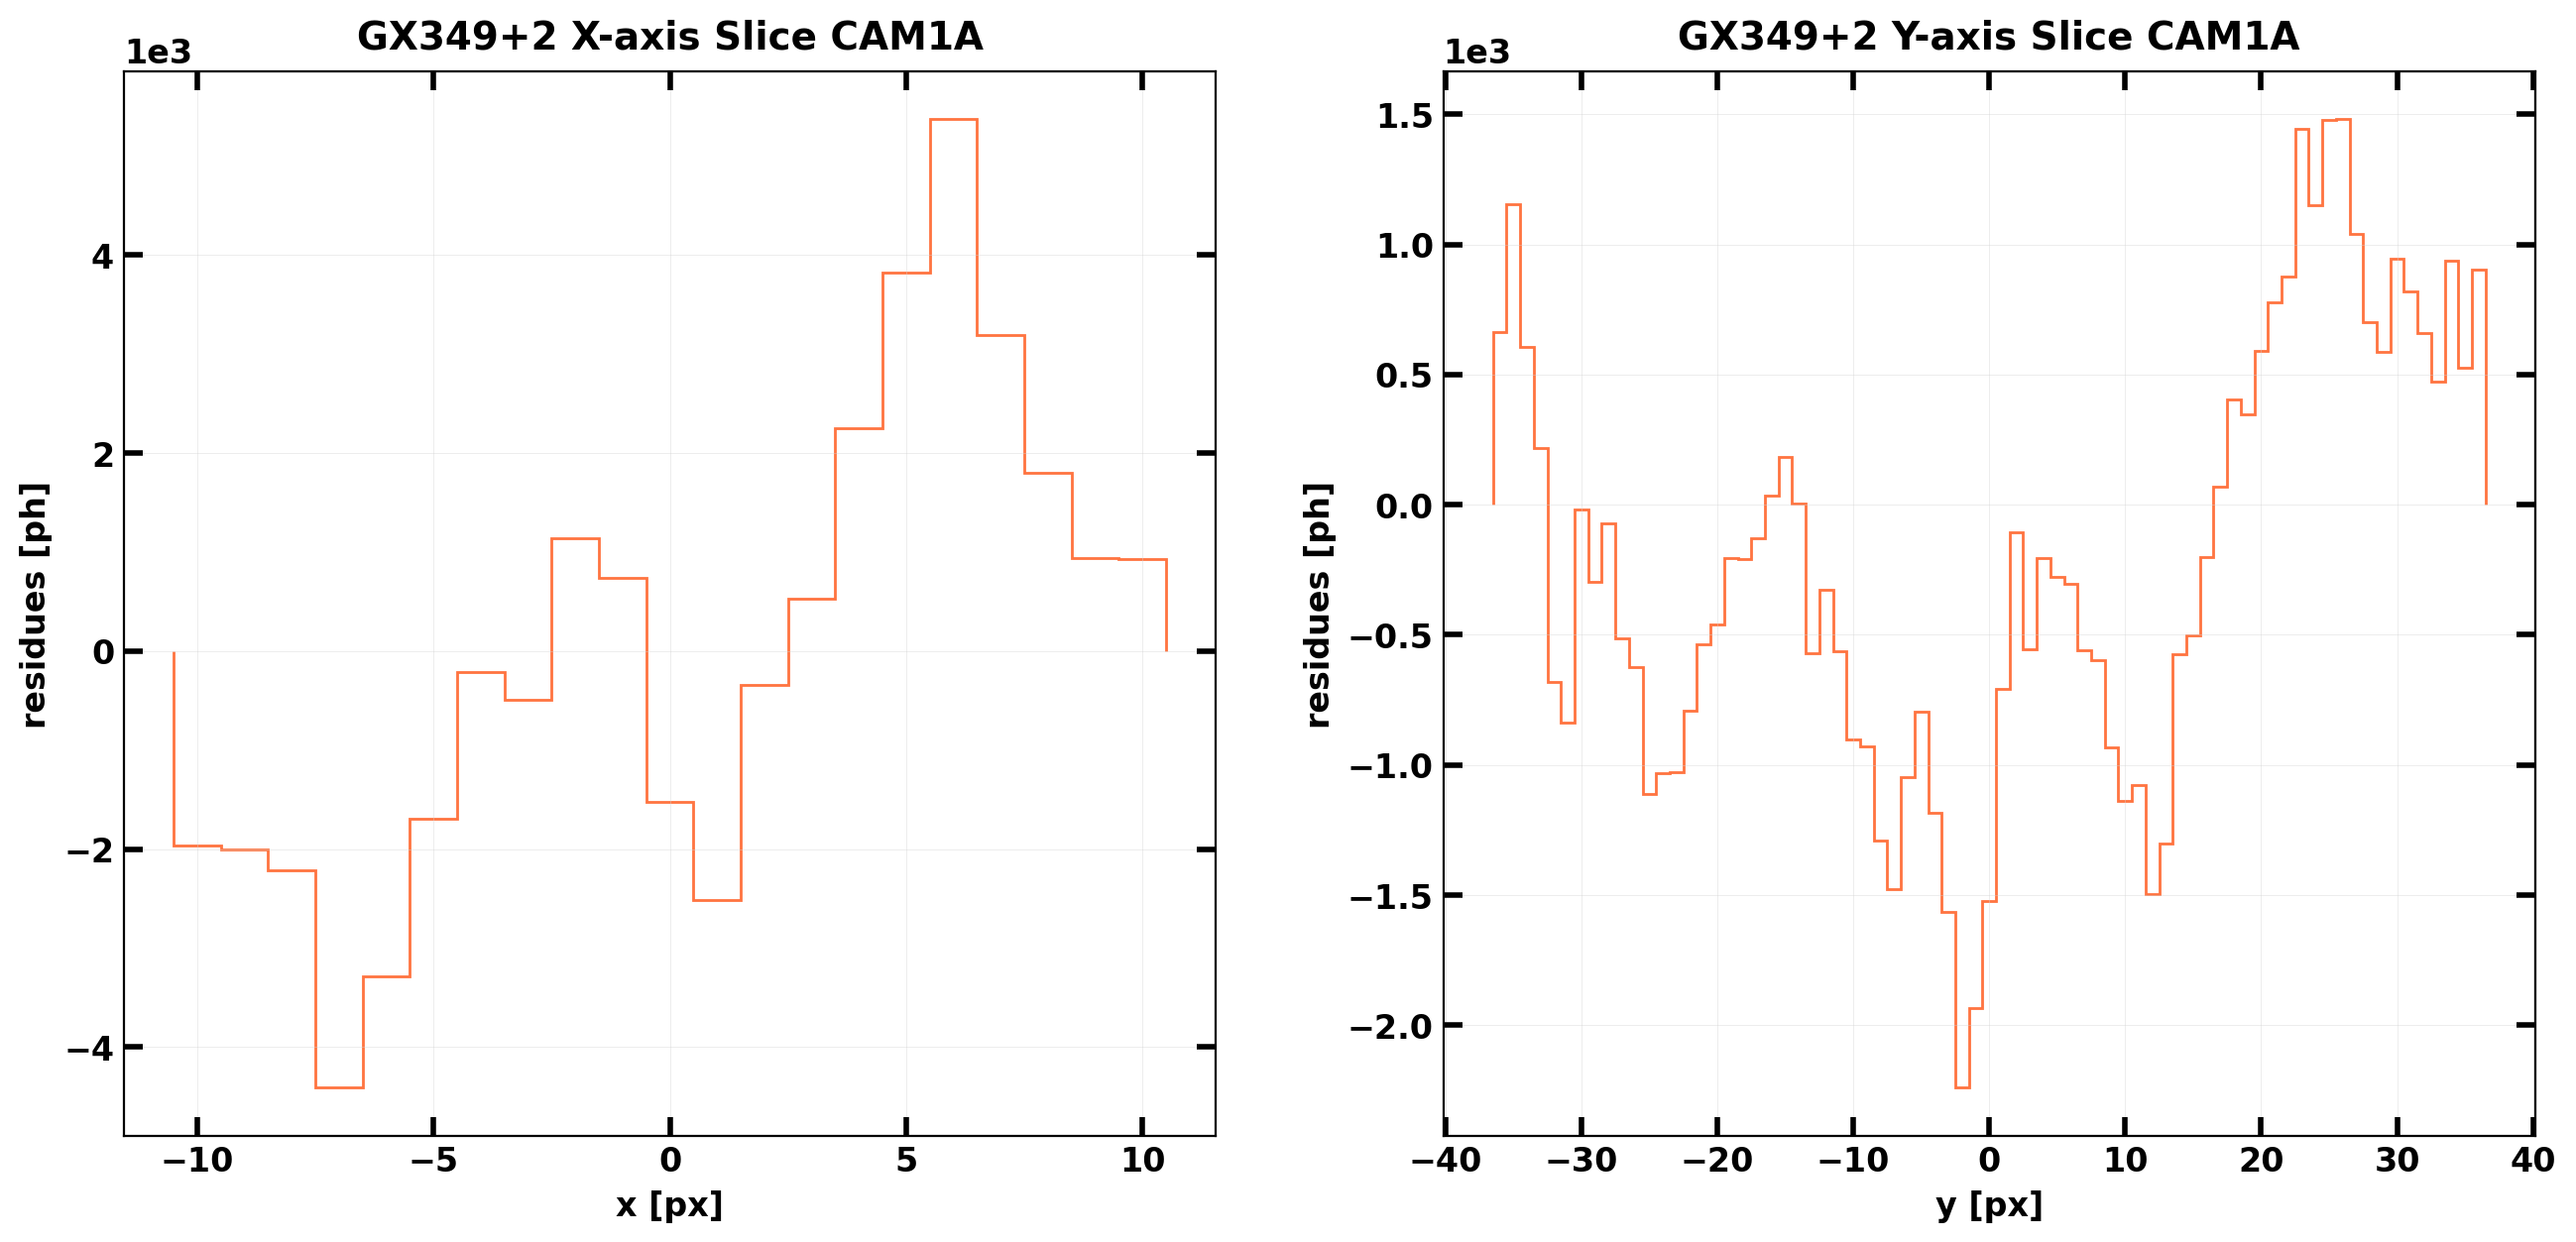

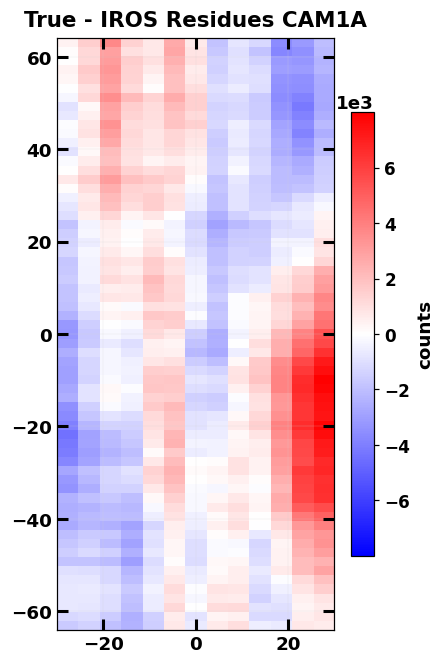

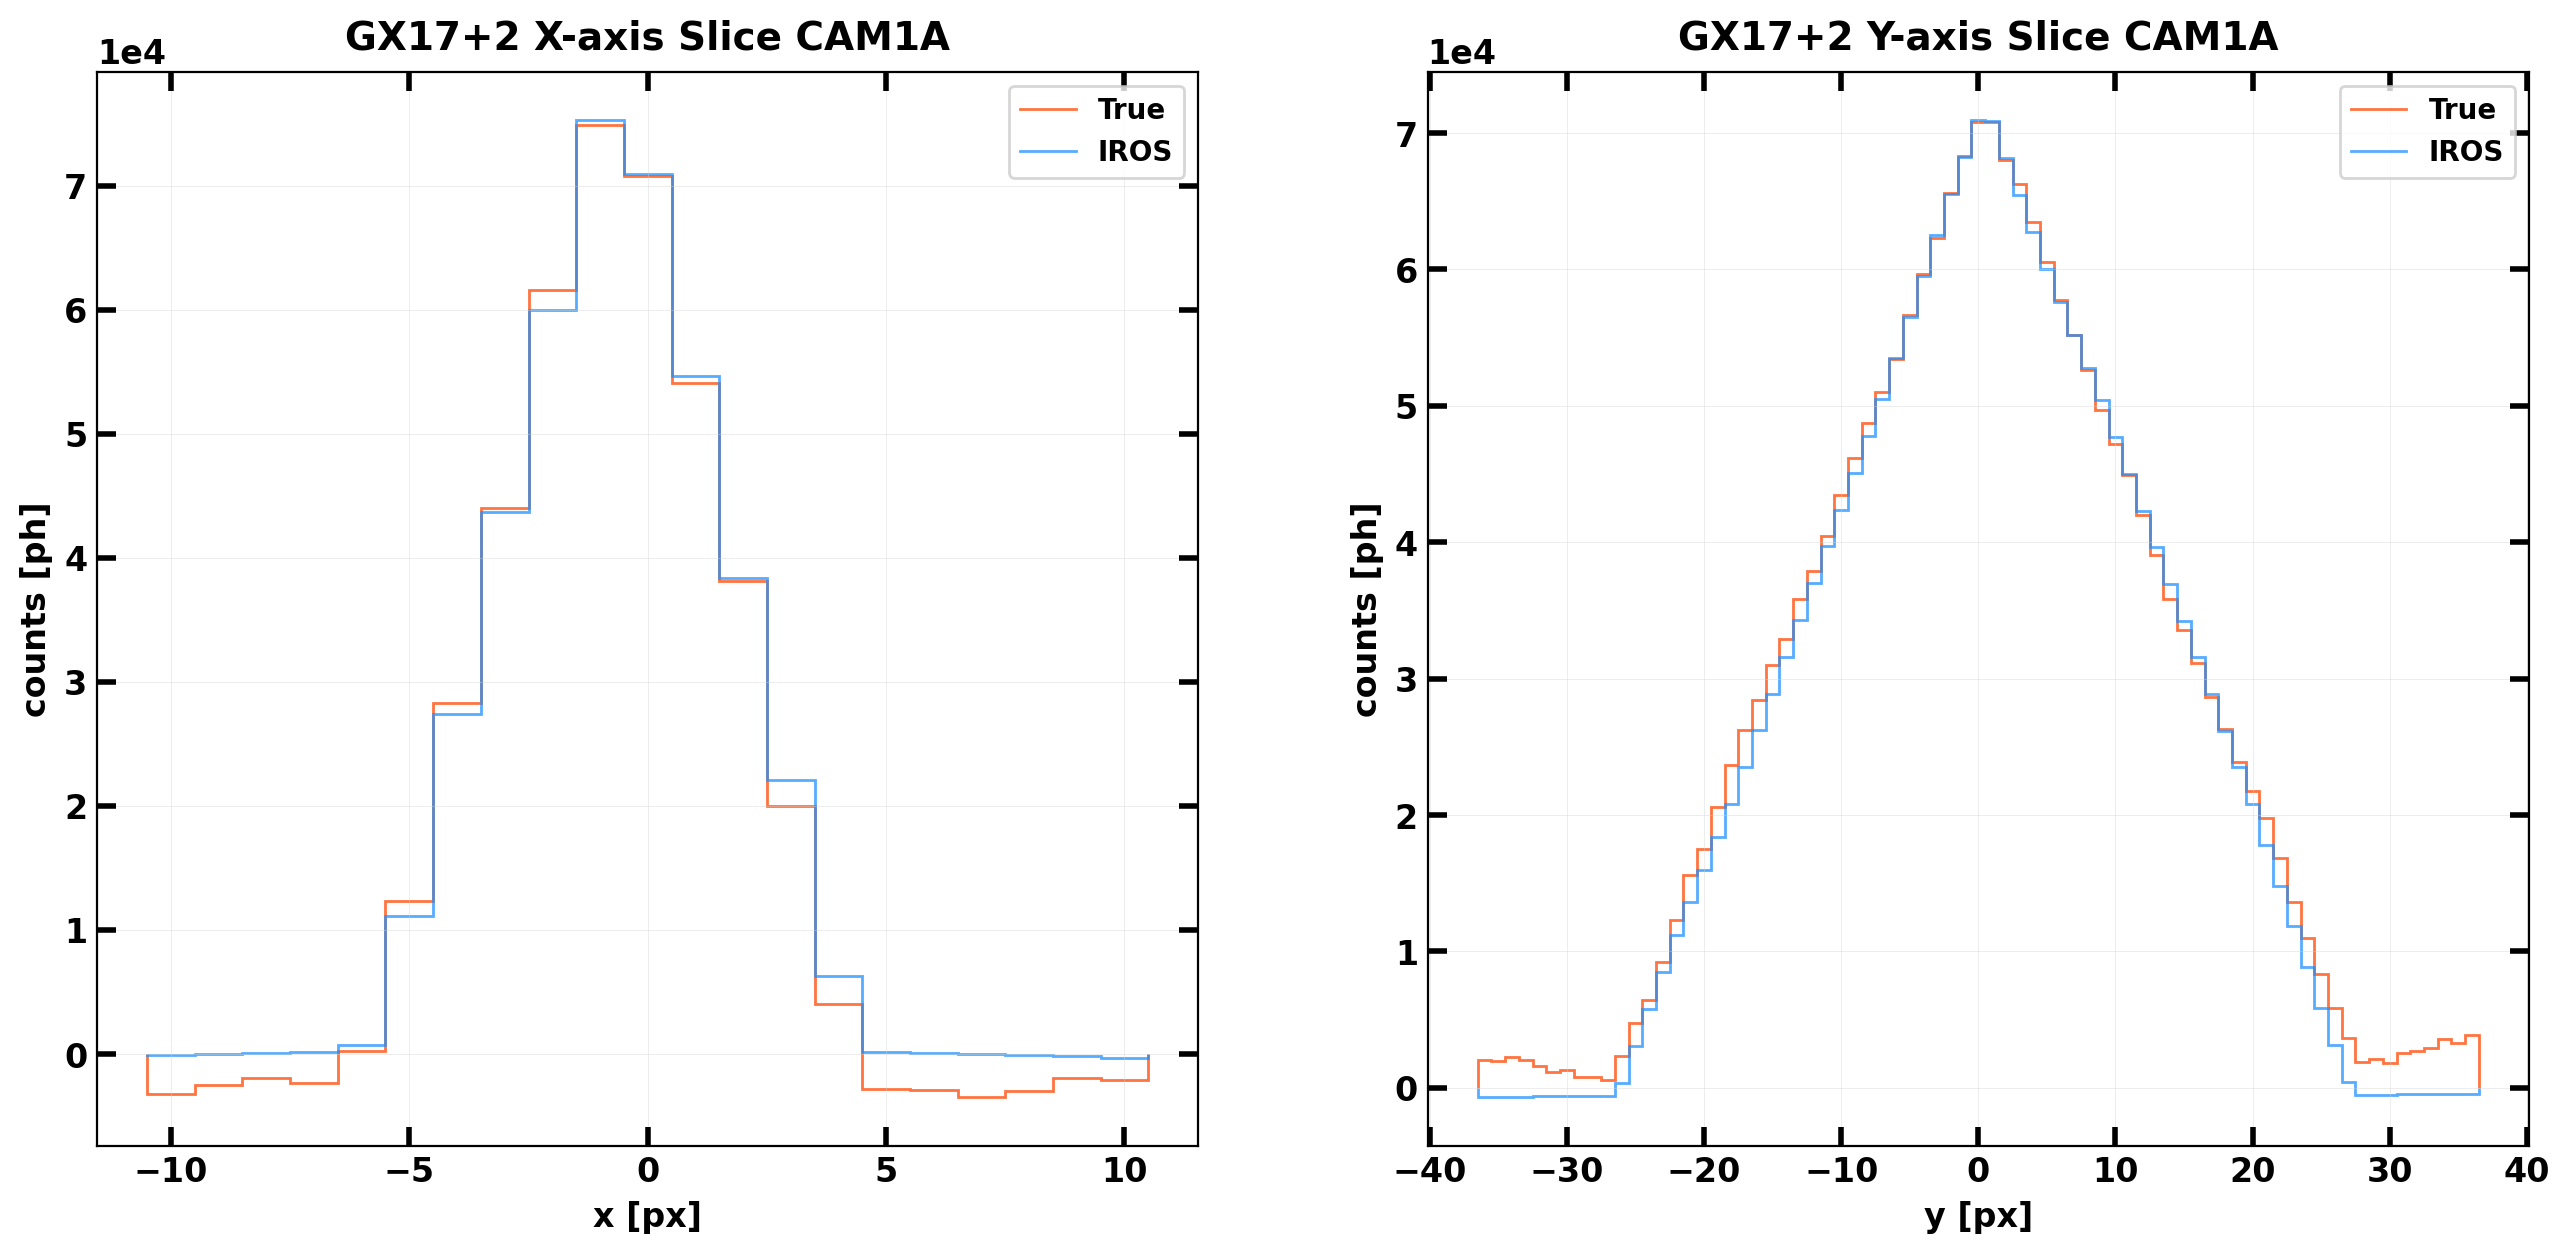

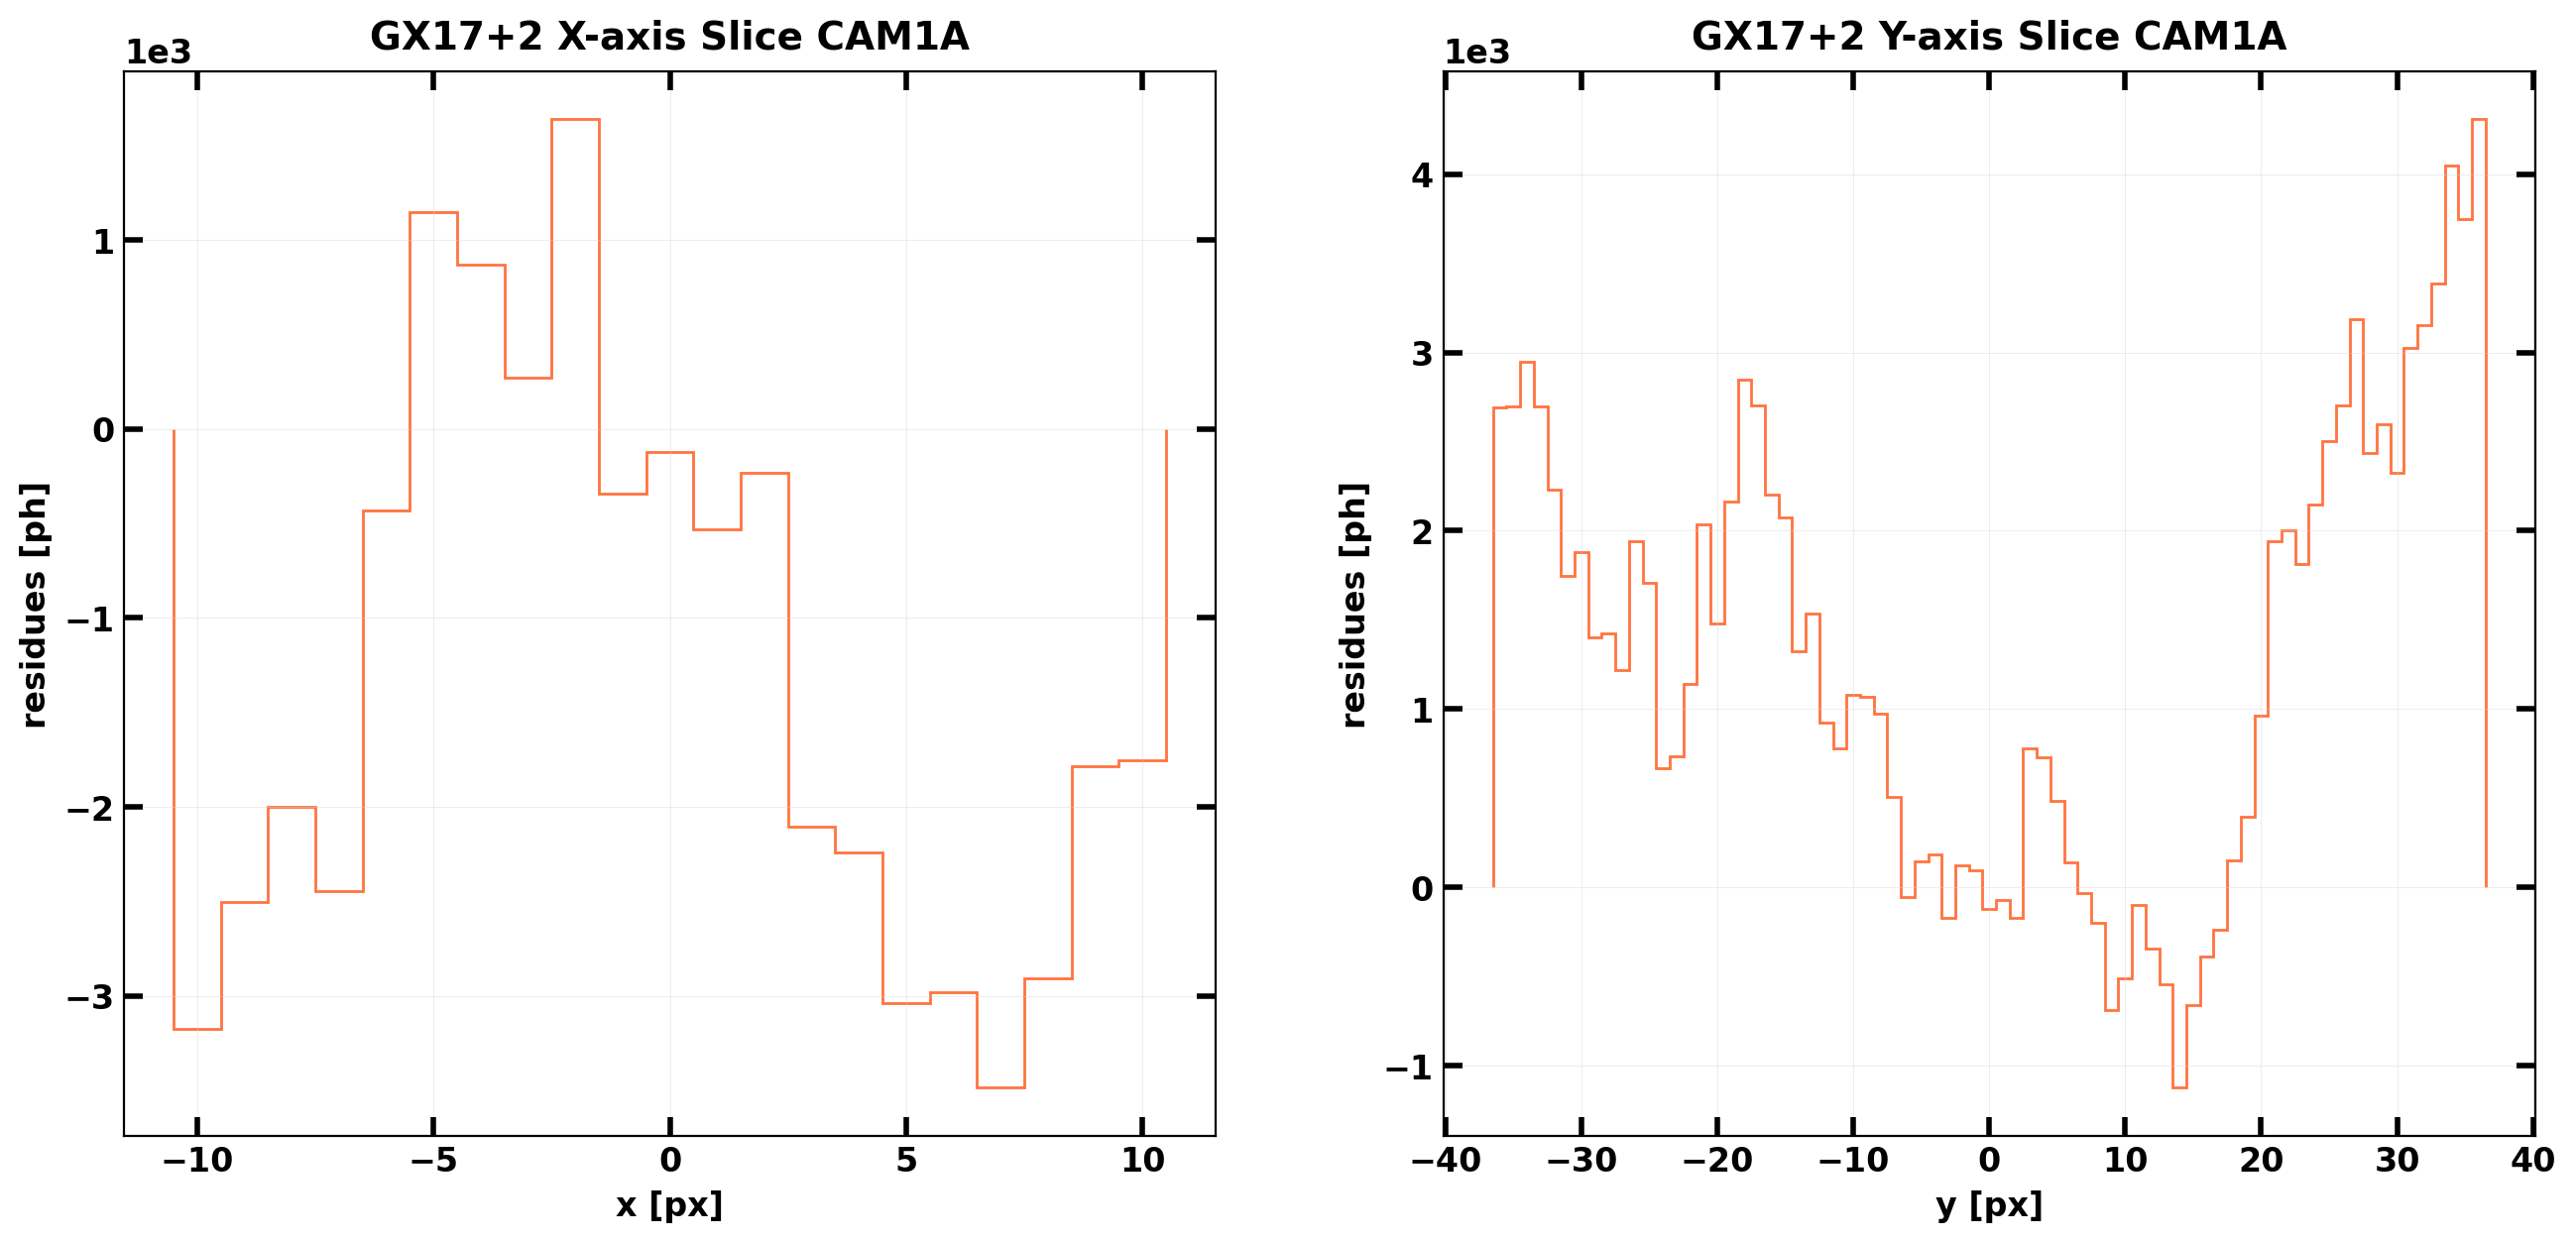

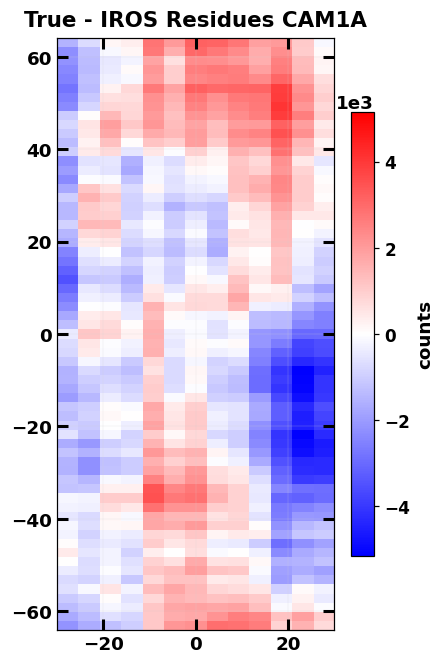

In [13]:
cropy, cropx = (
    int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 5),
    int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 5),
)
reconstruction_plot(
    true_sky=simul_sky_camA,
    log=log_camA,
    crp=(cropy, cropx),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    #savepath=is_img,
)

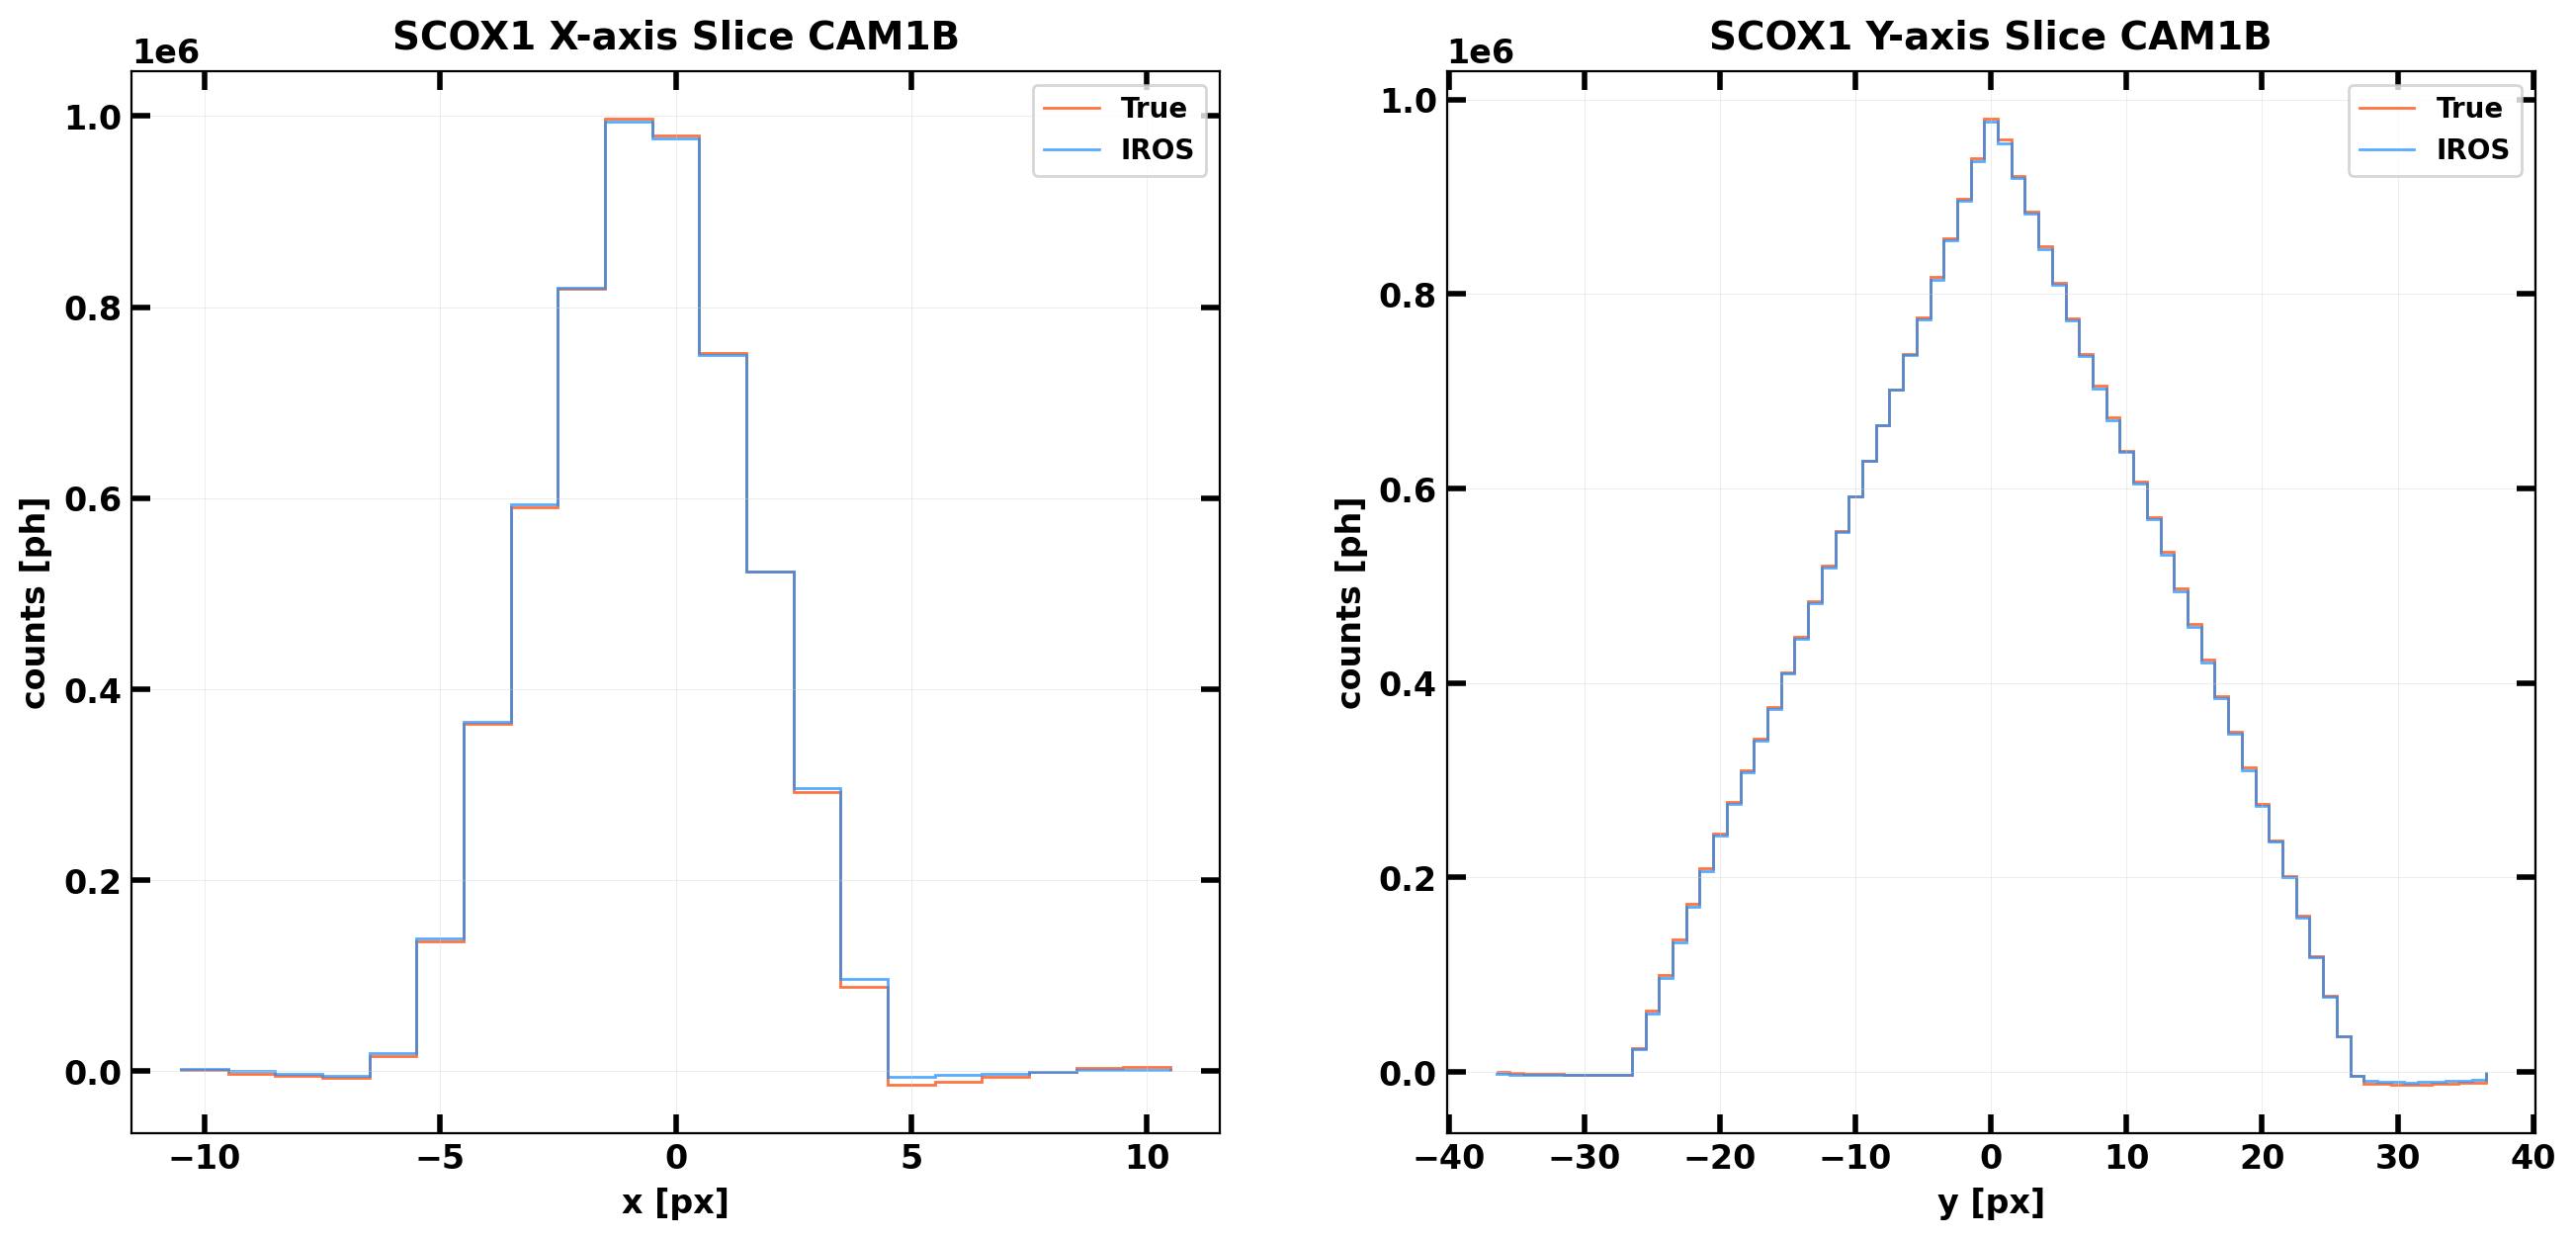

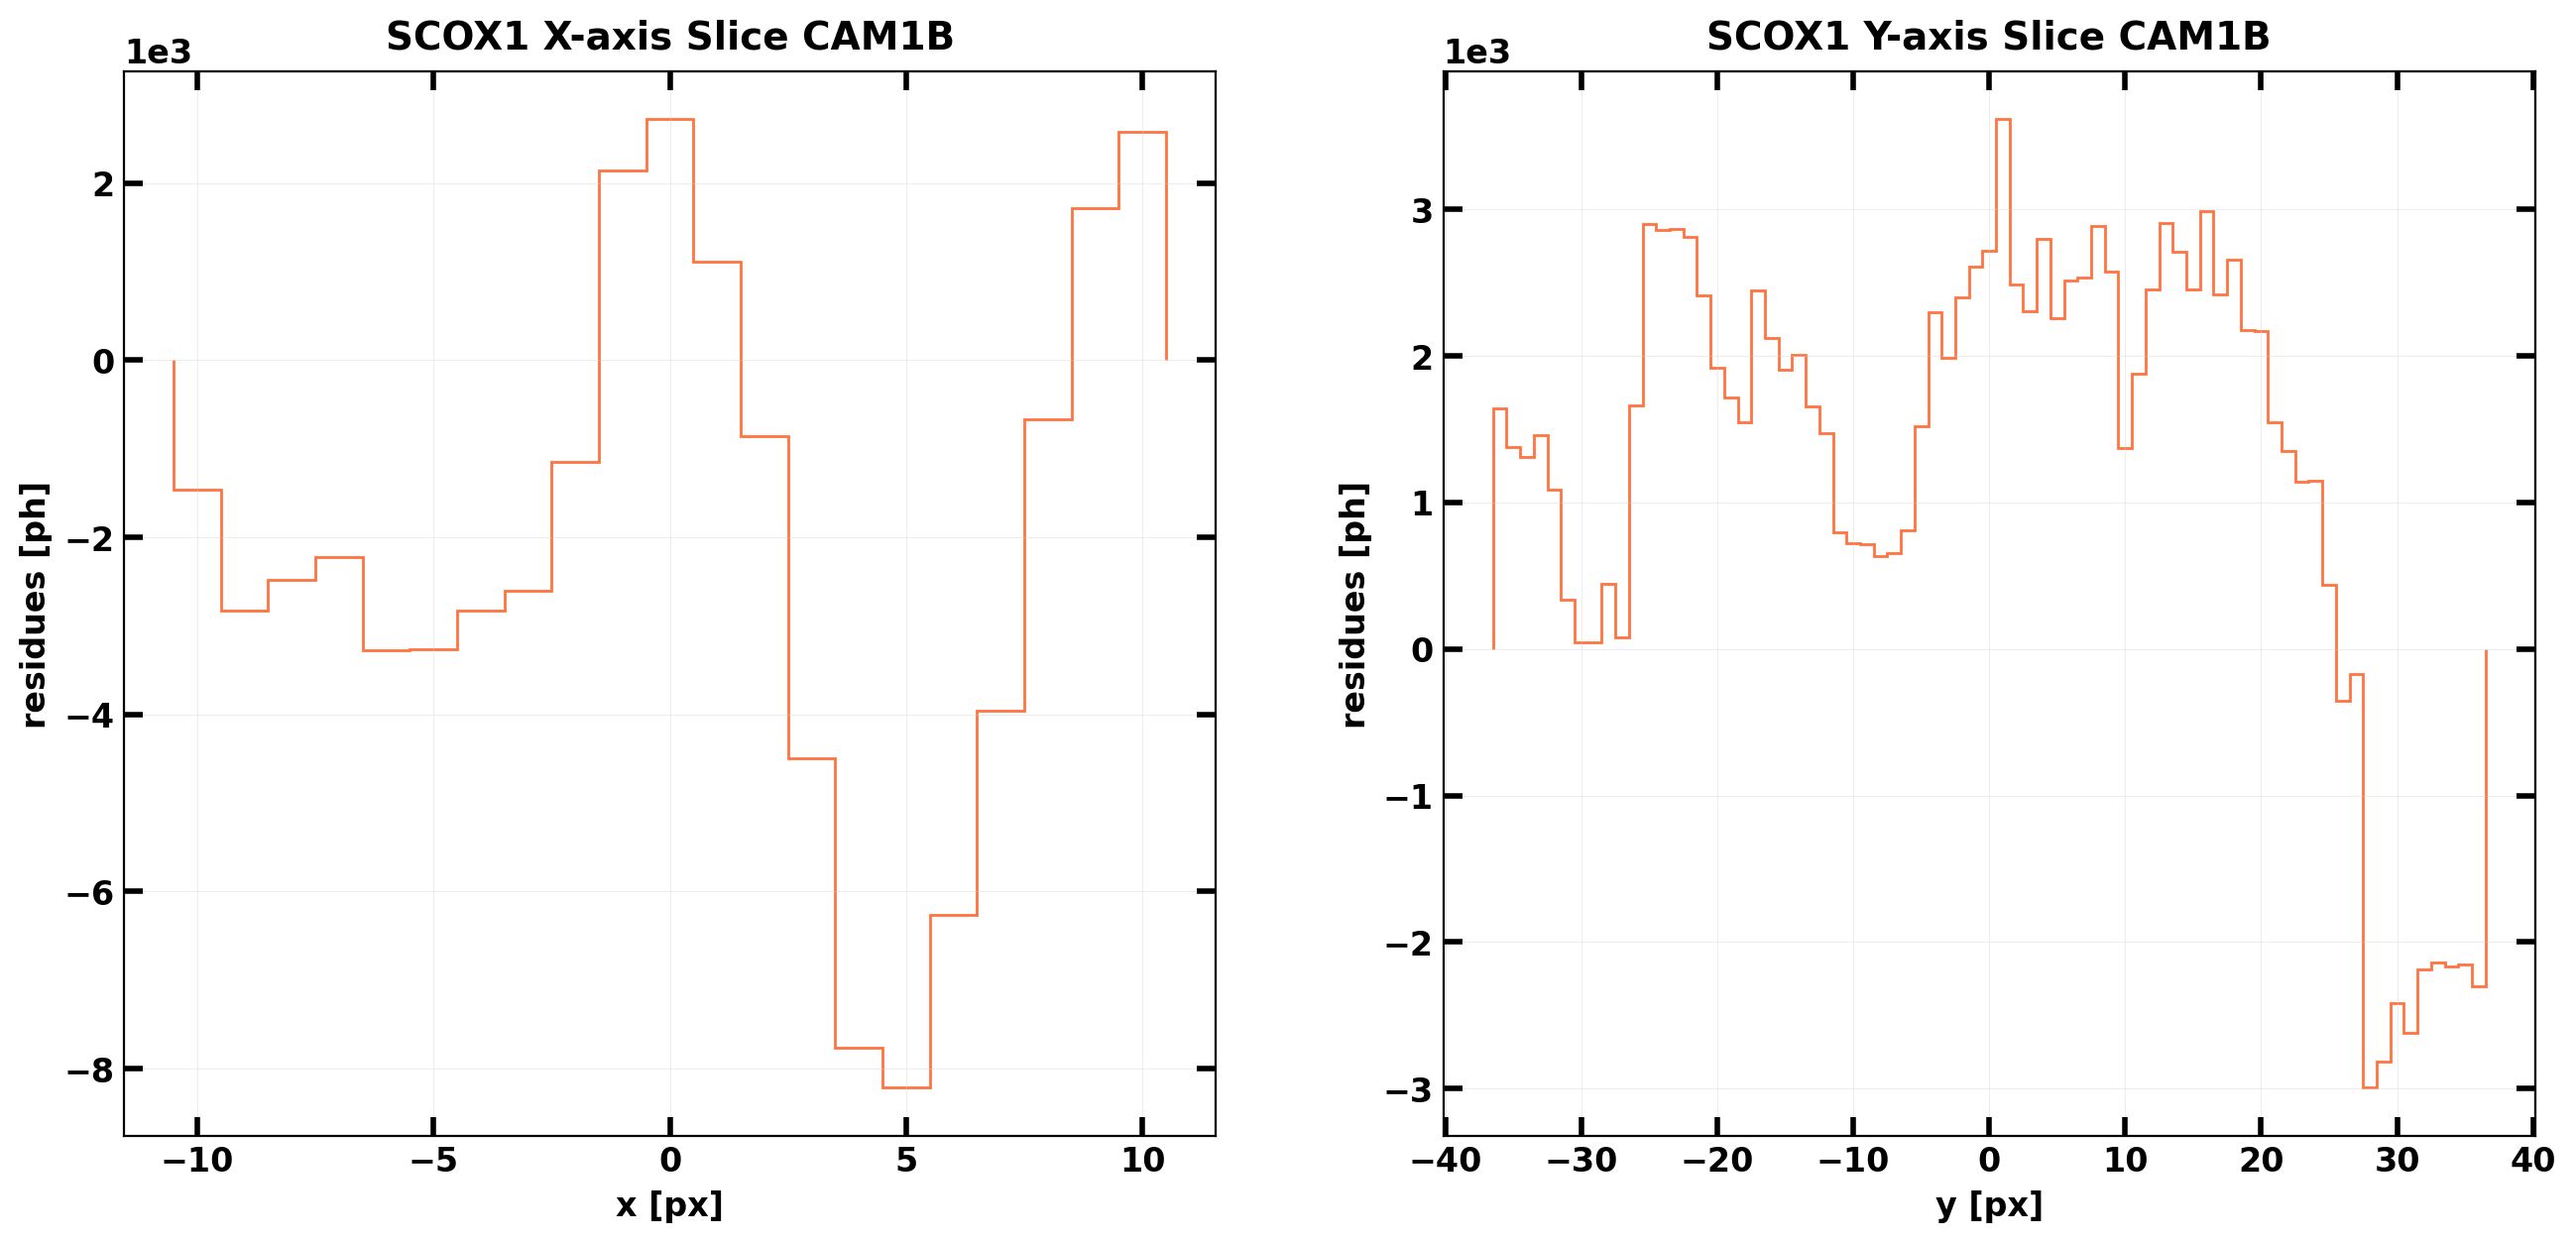

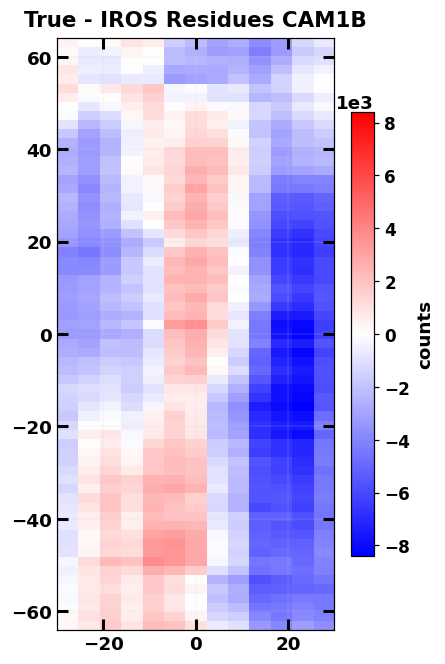

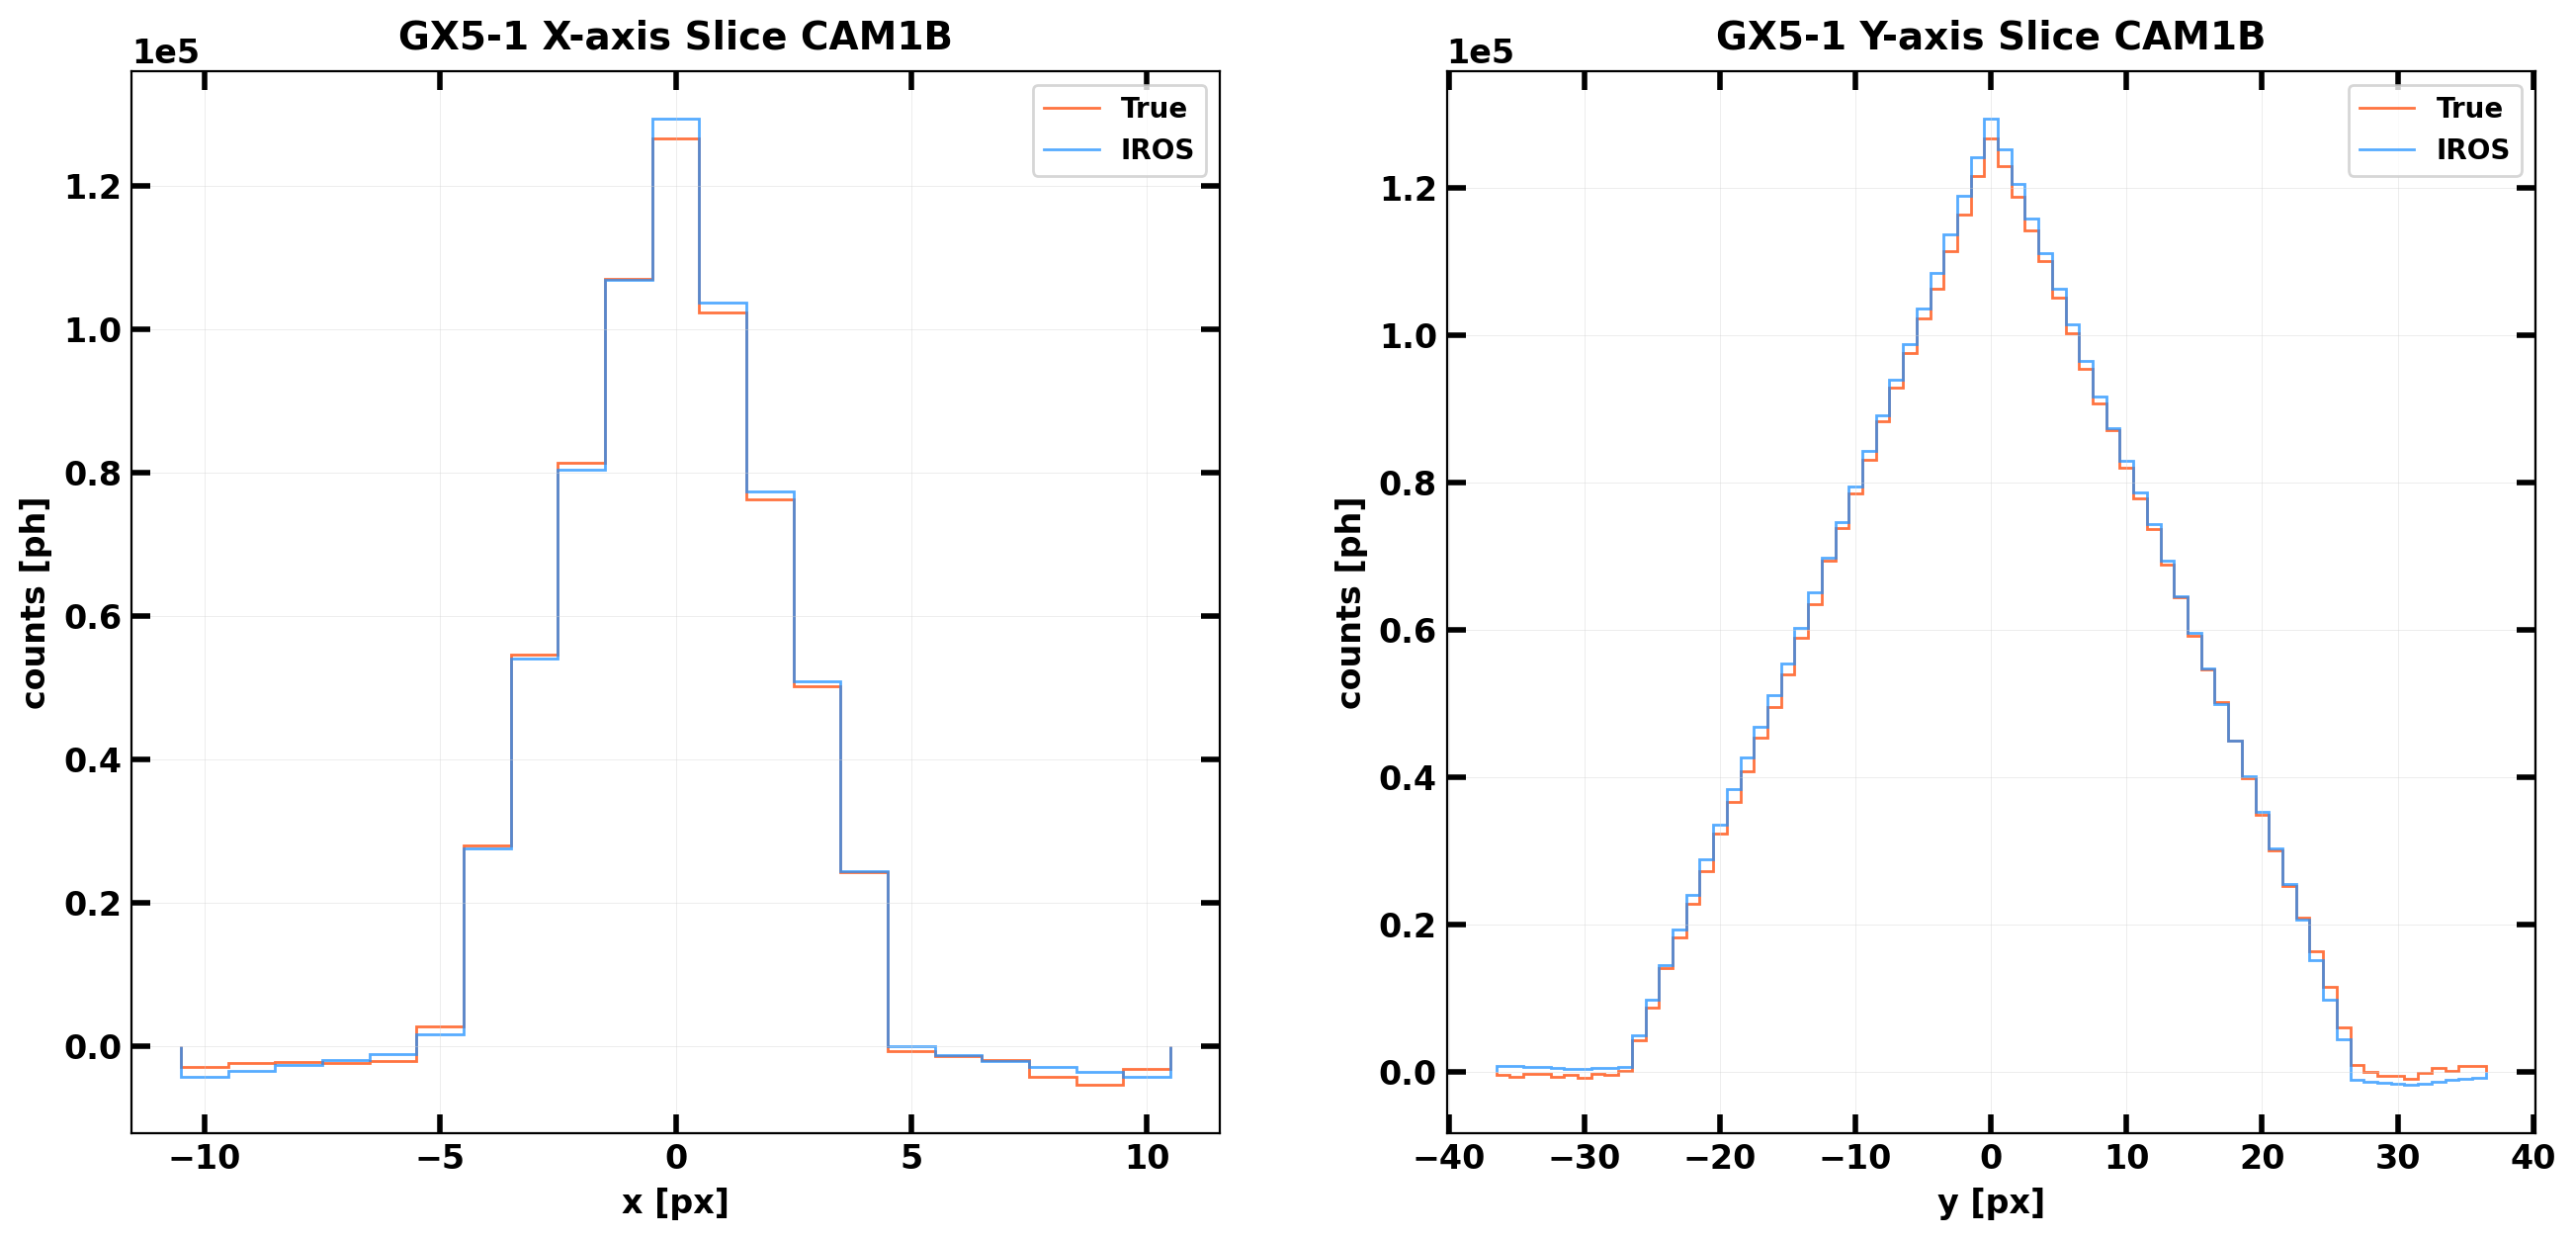

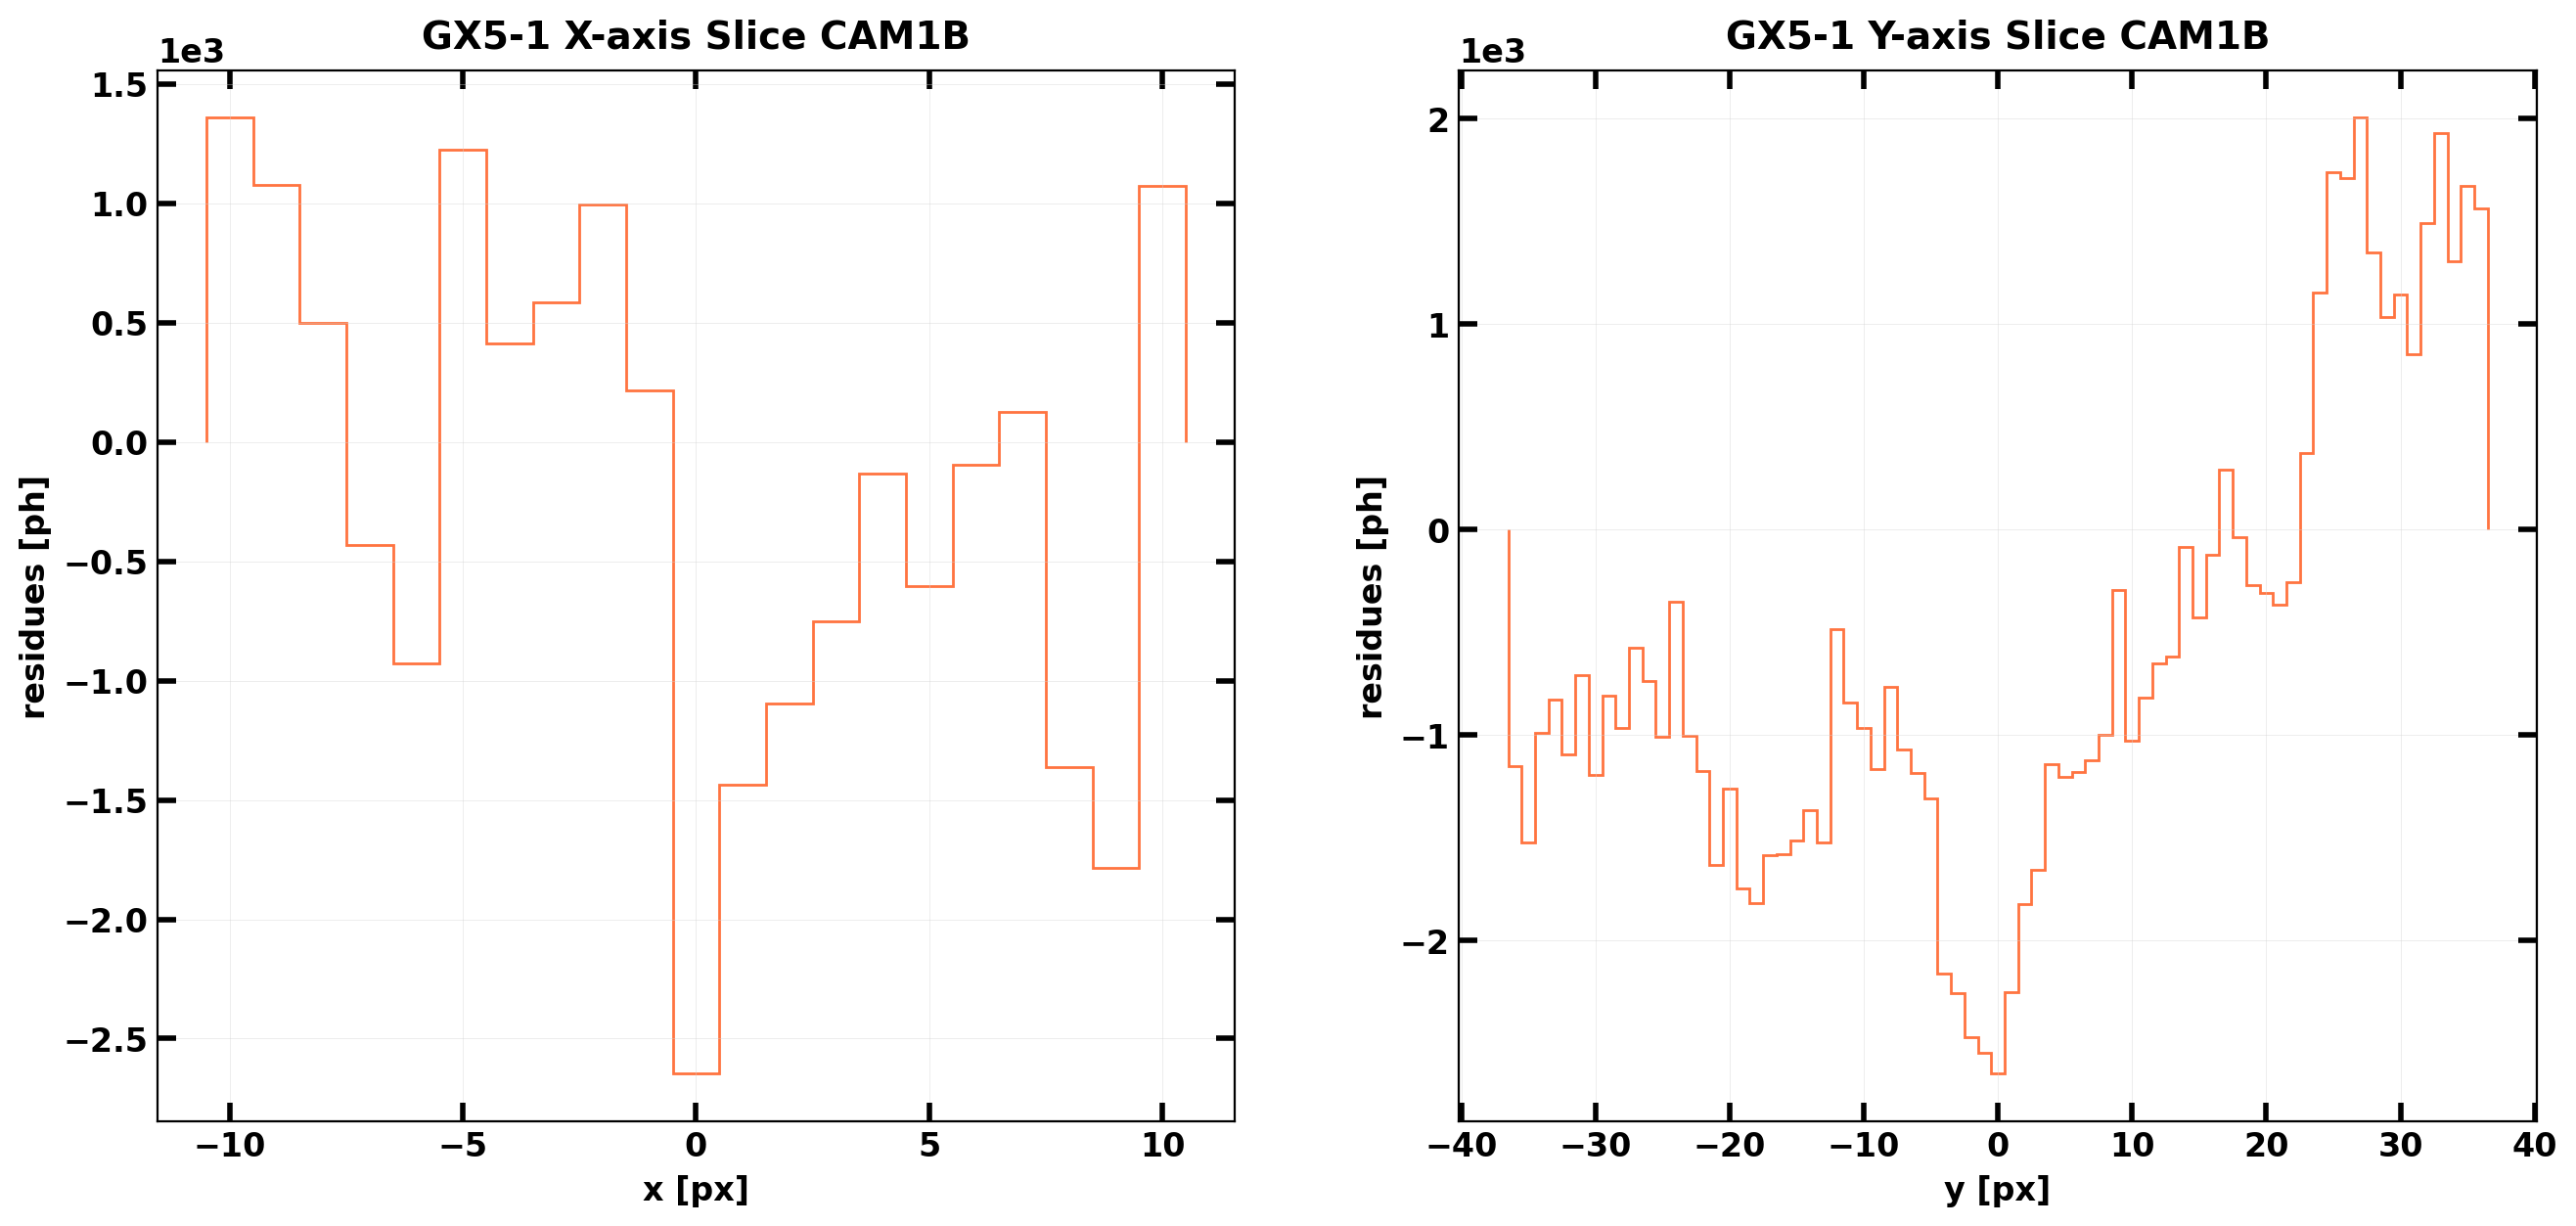

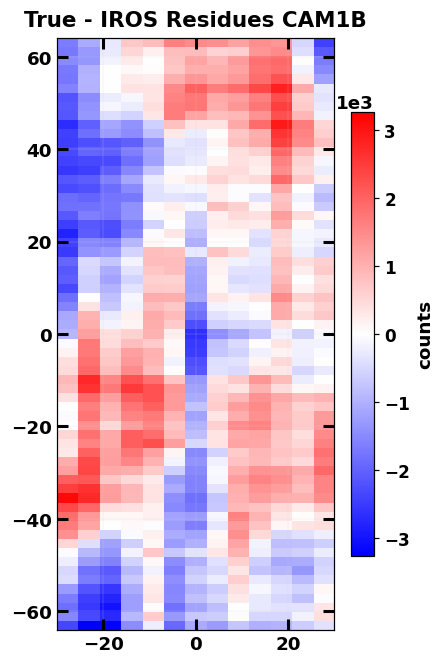

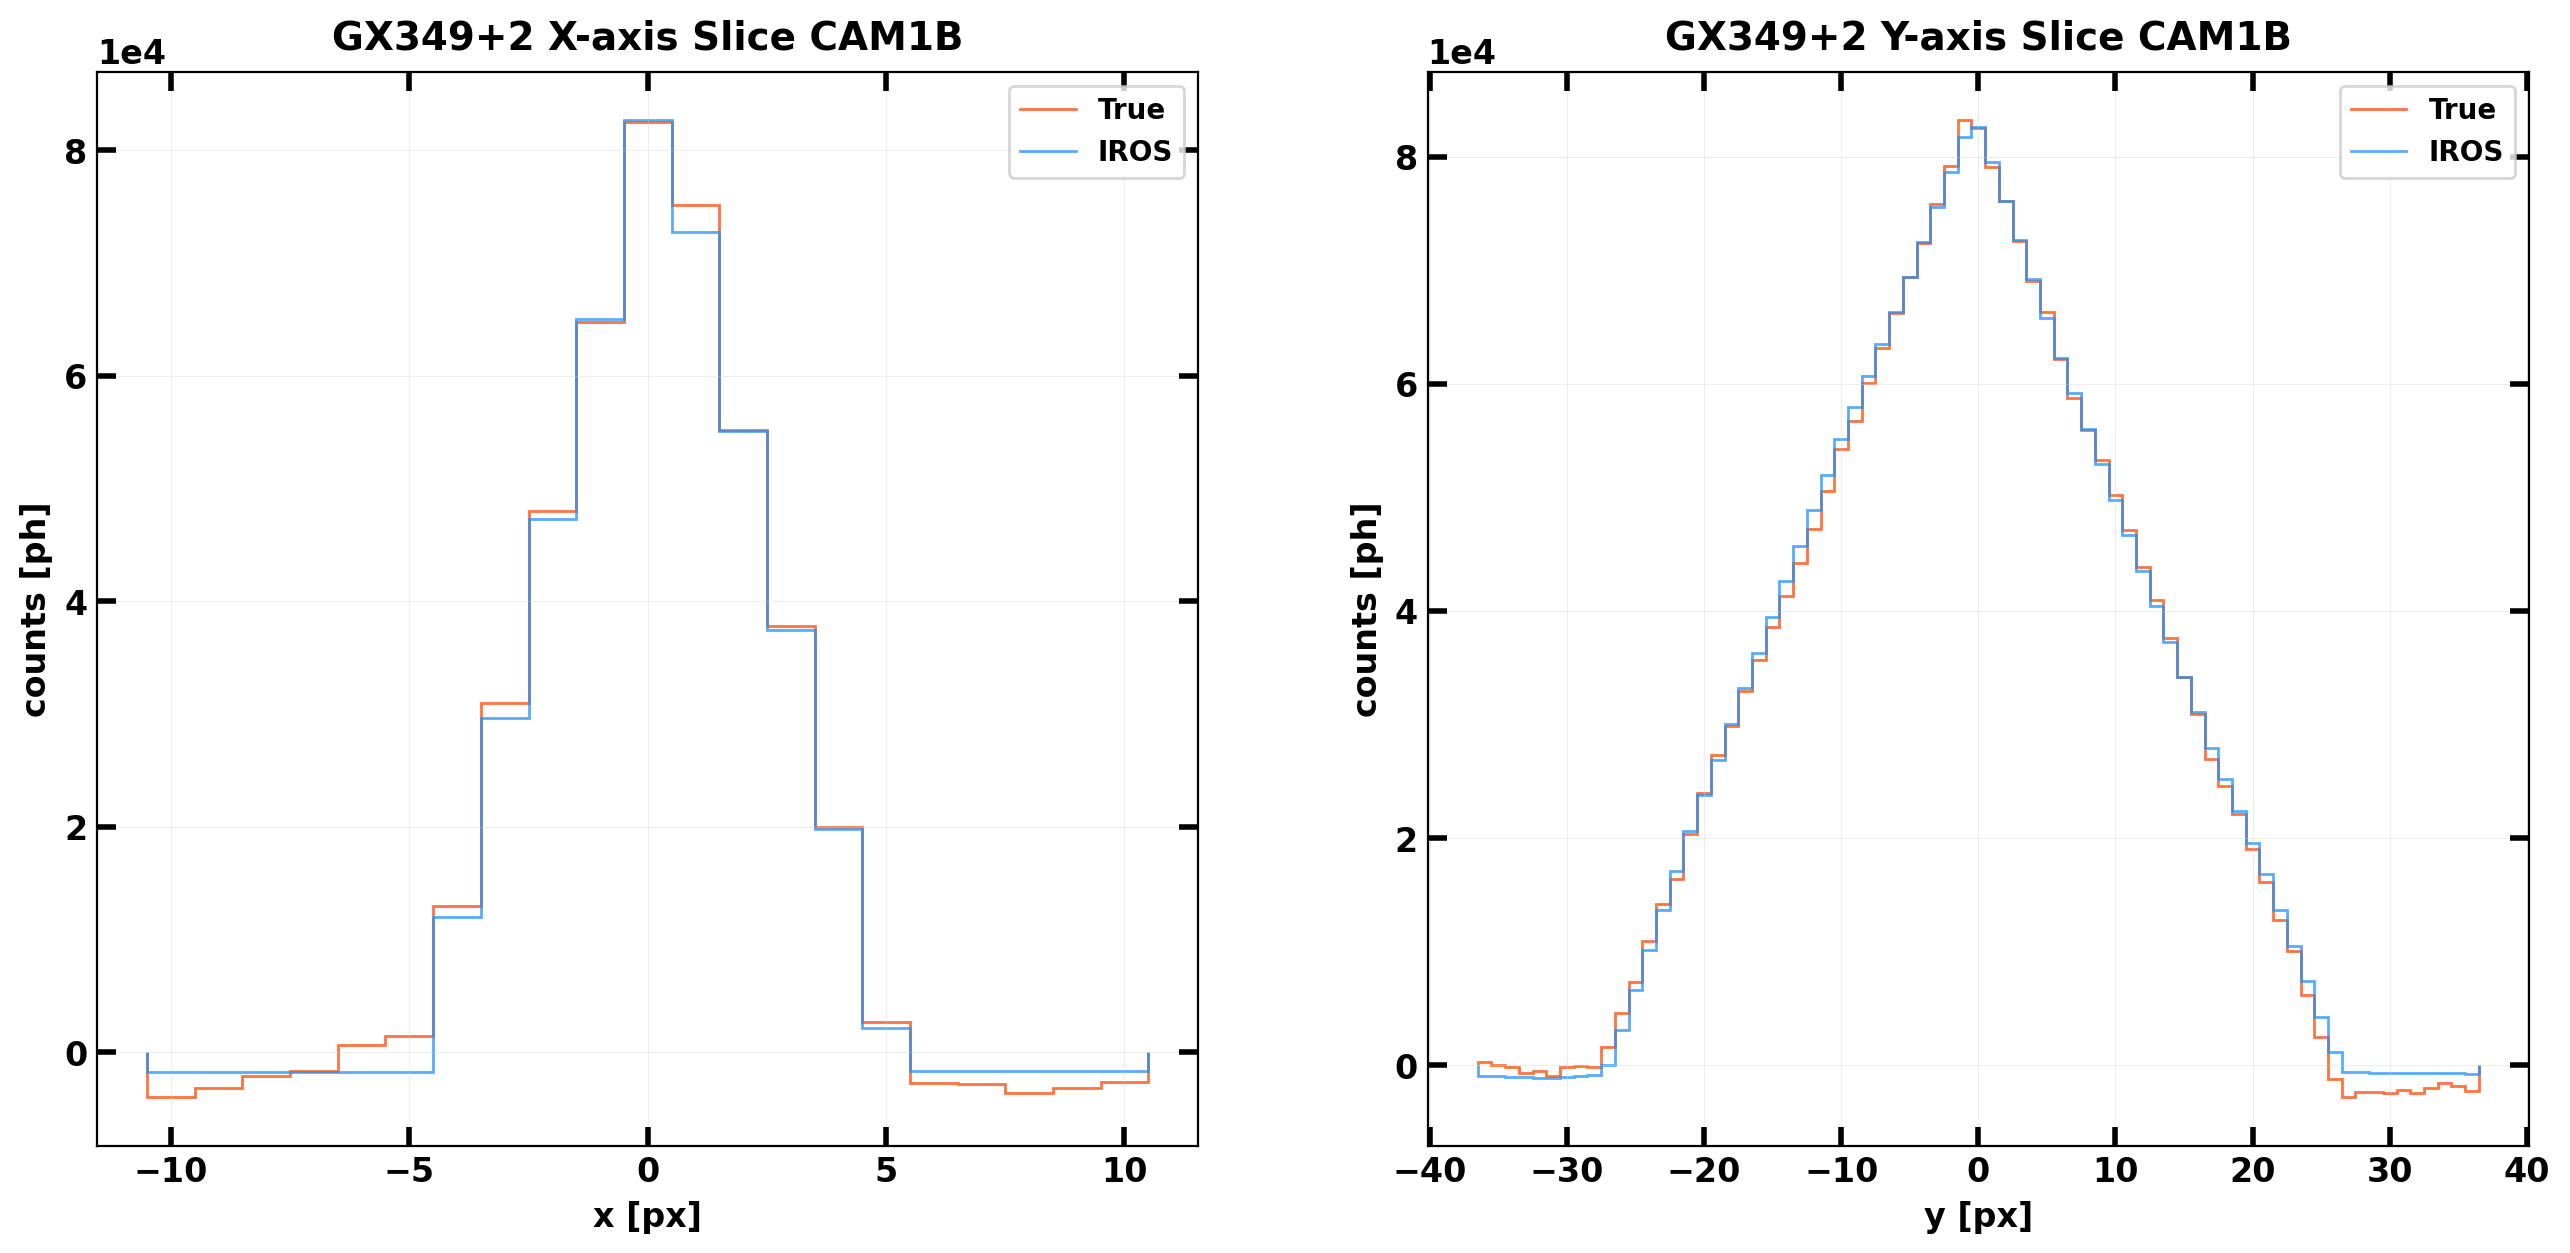

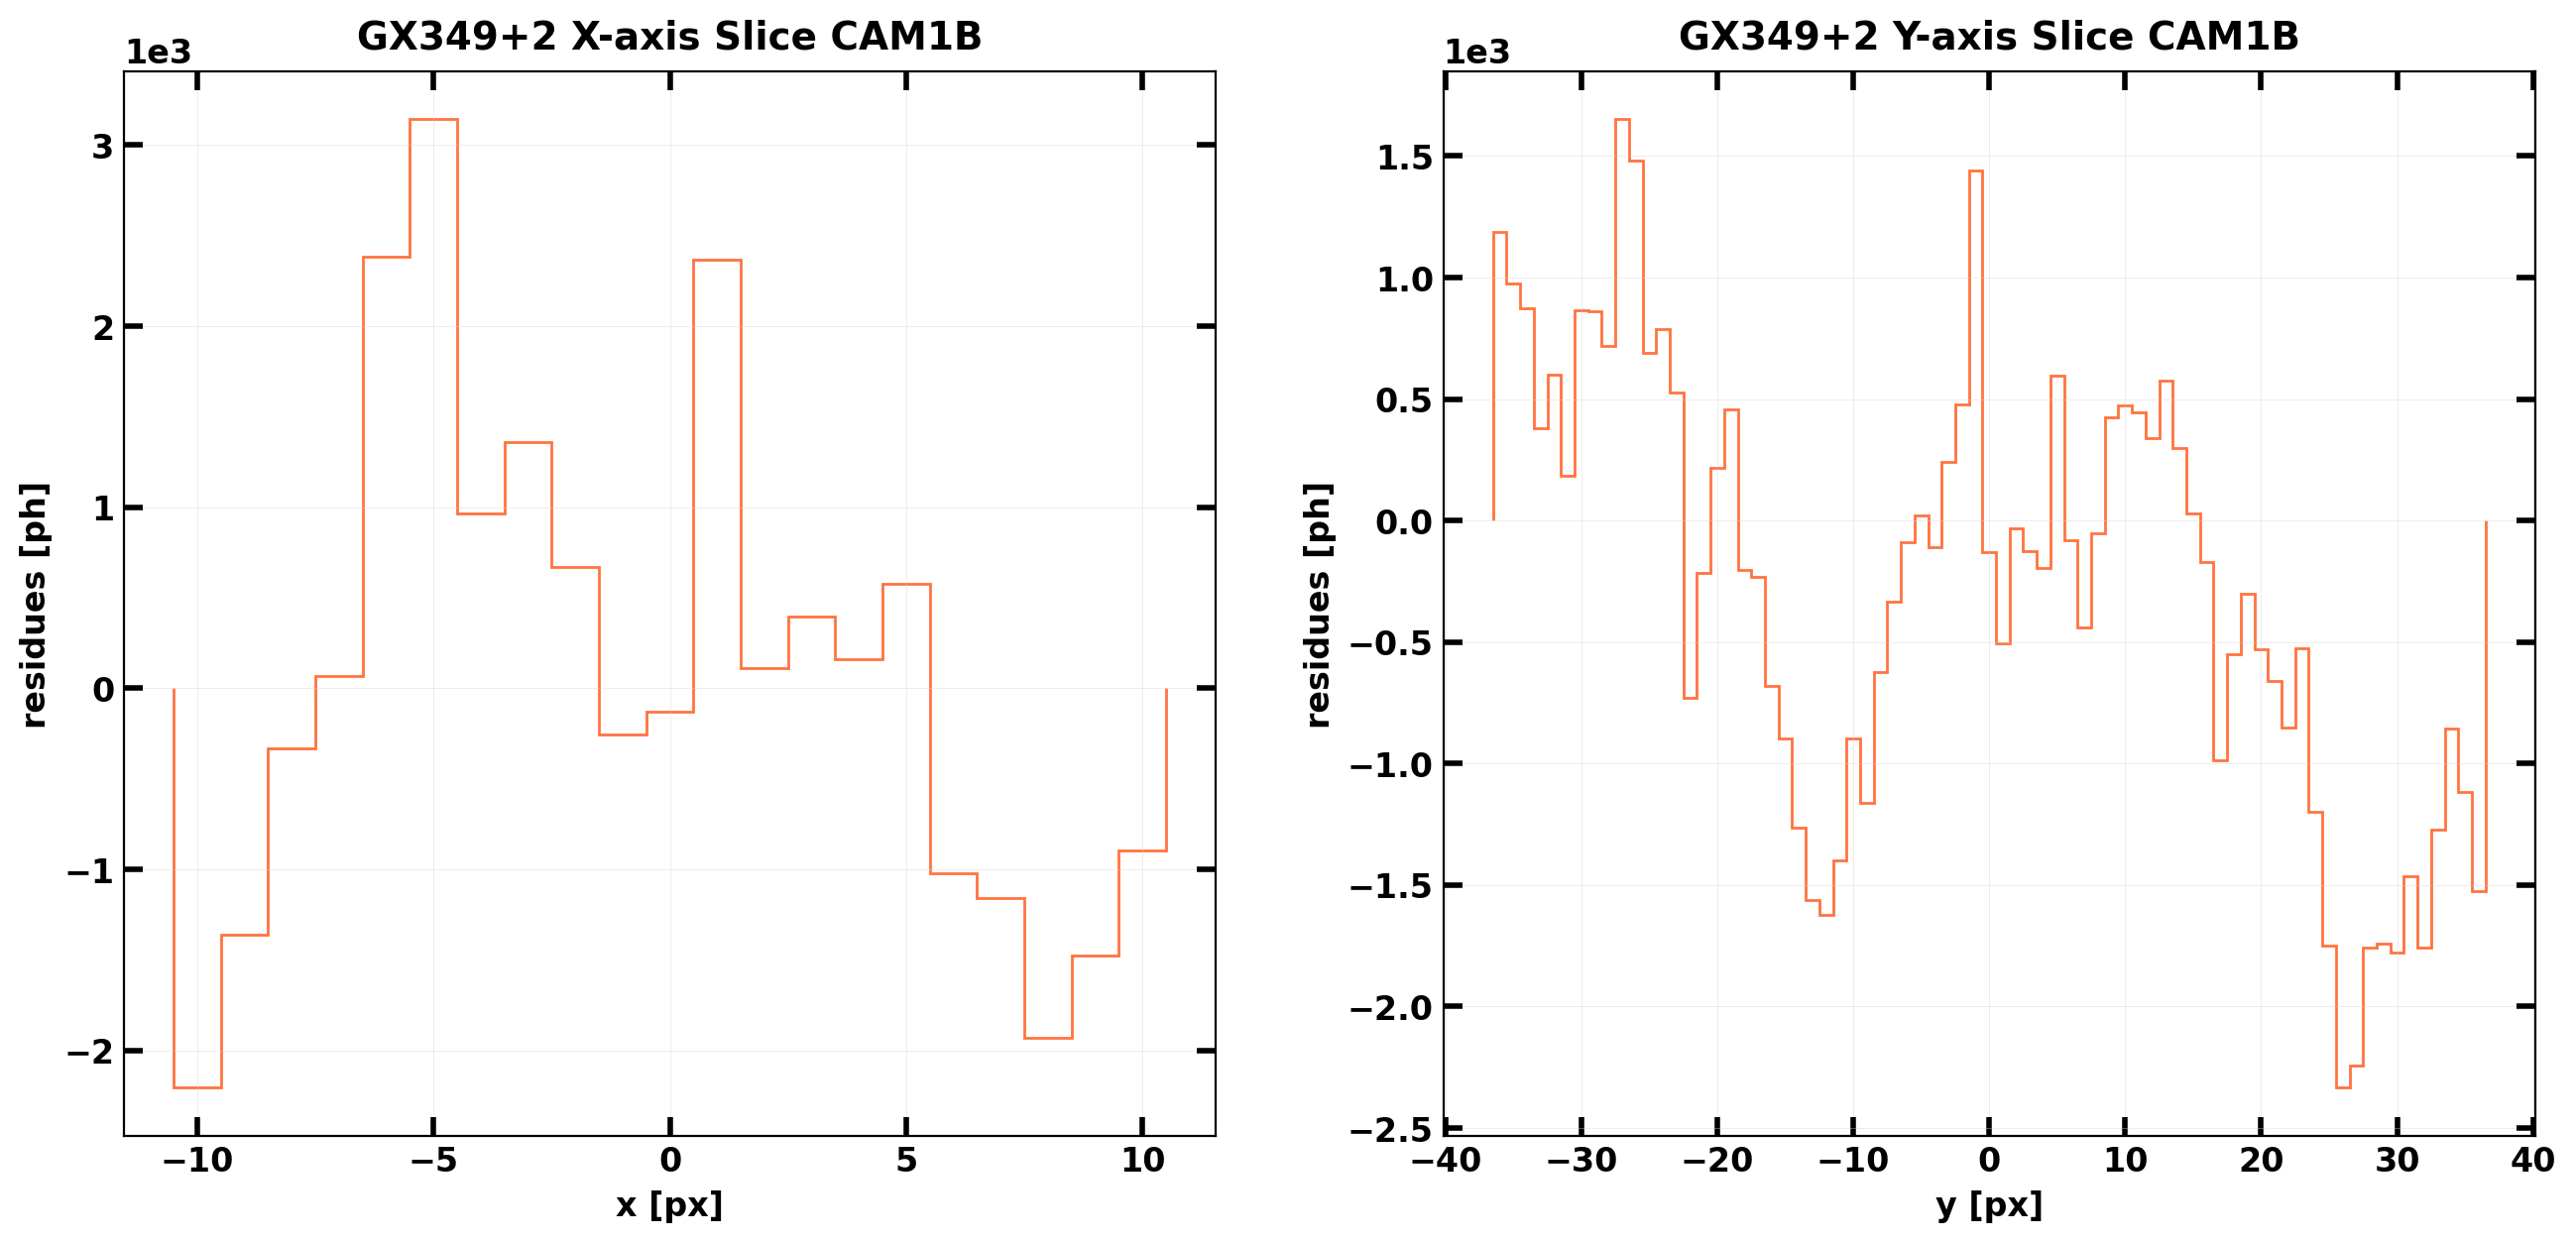

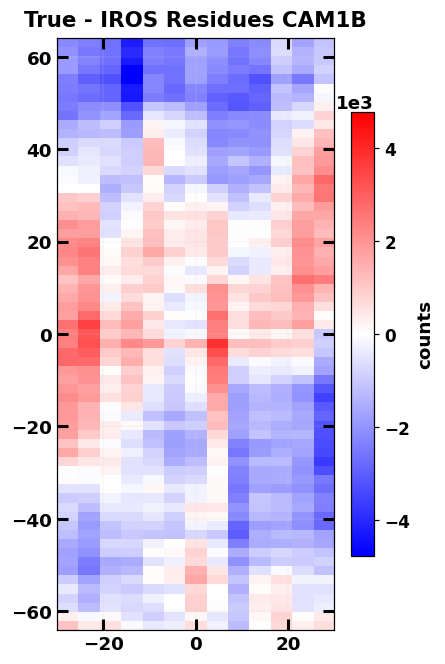

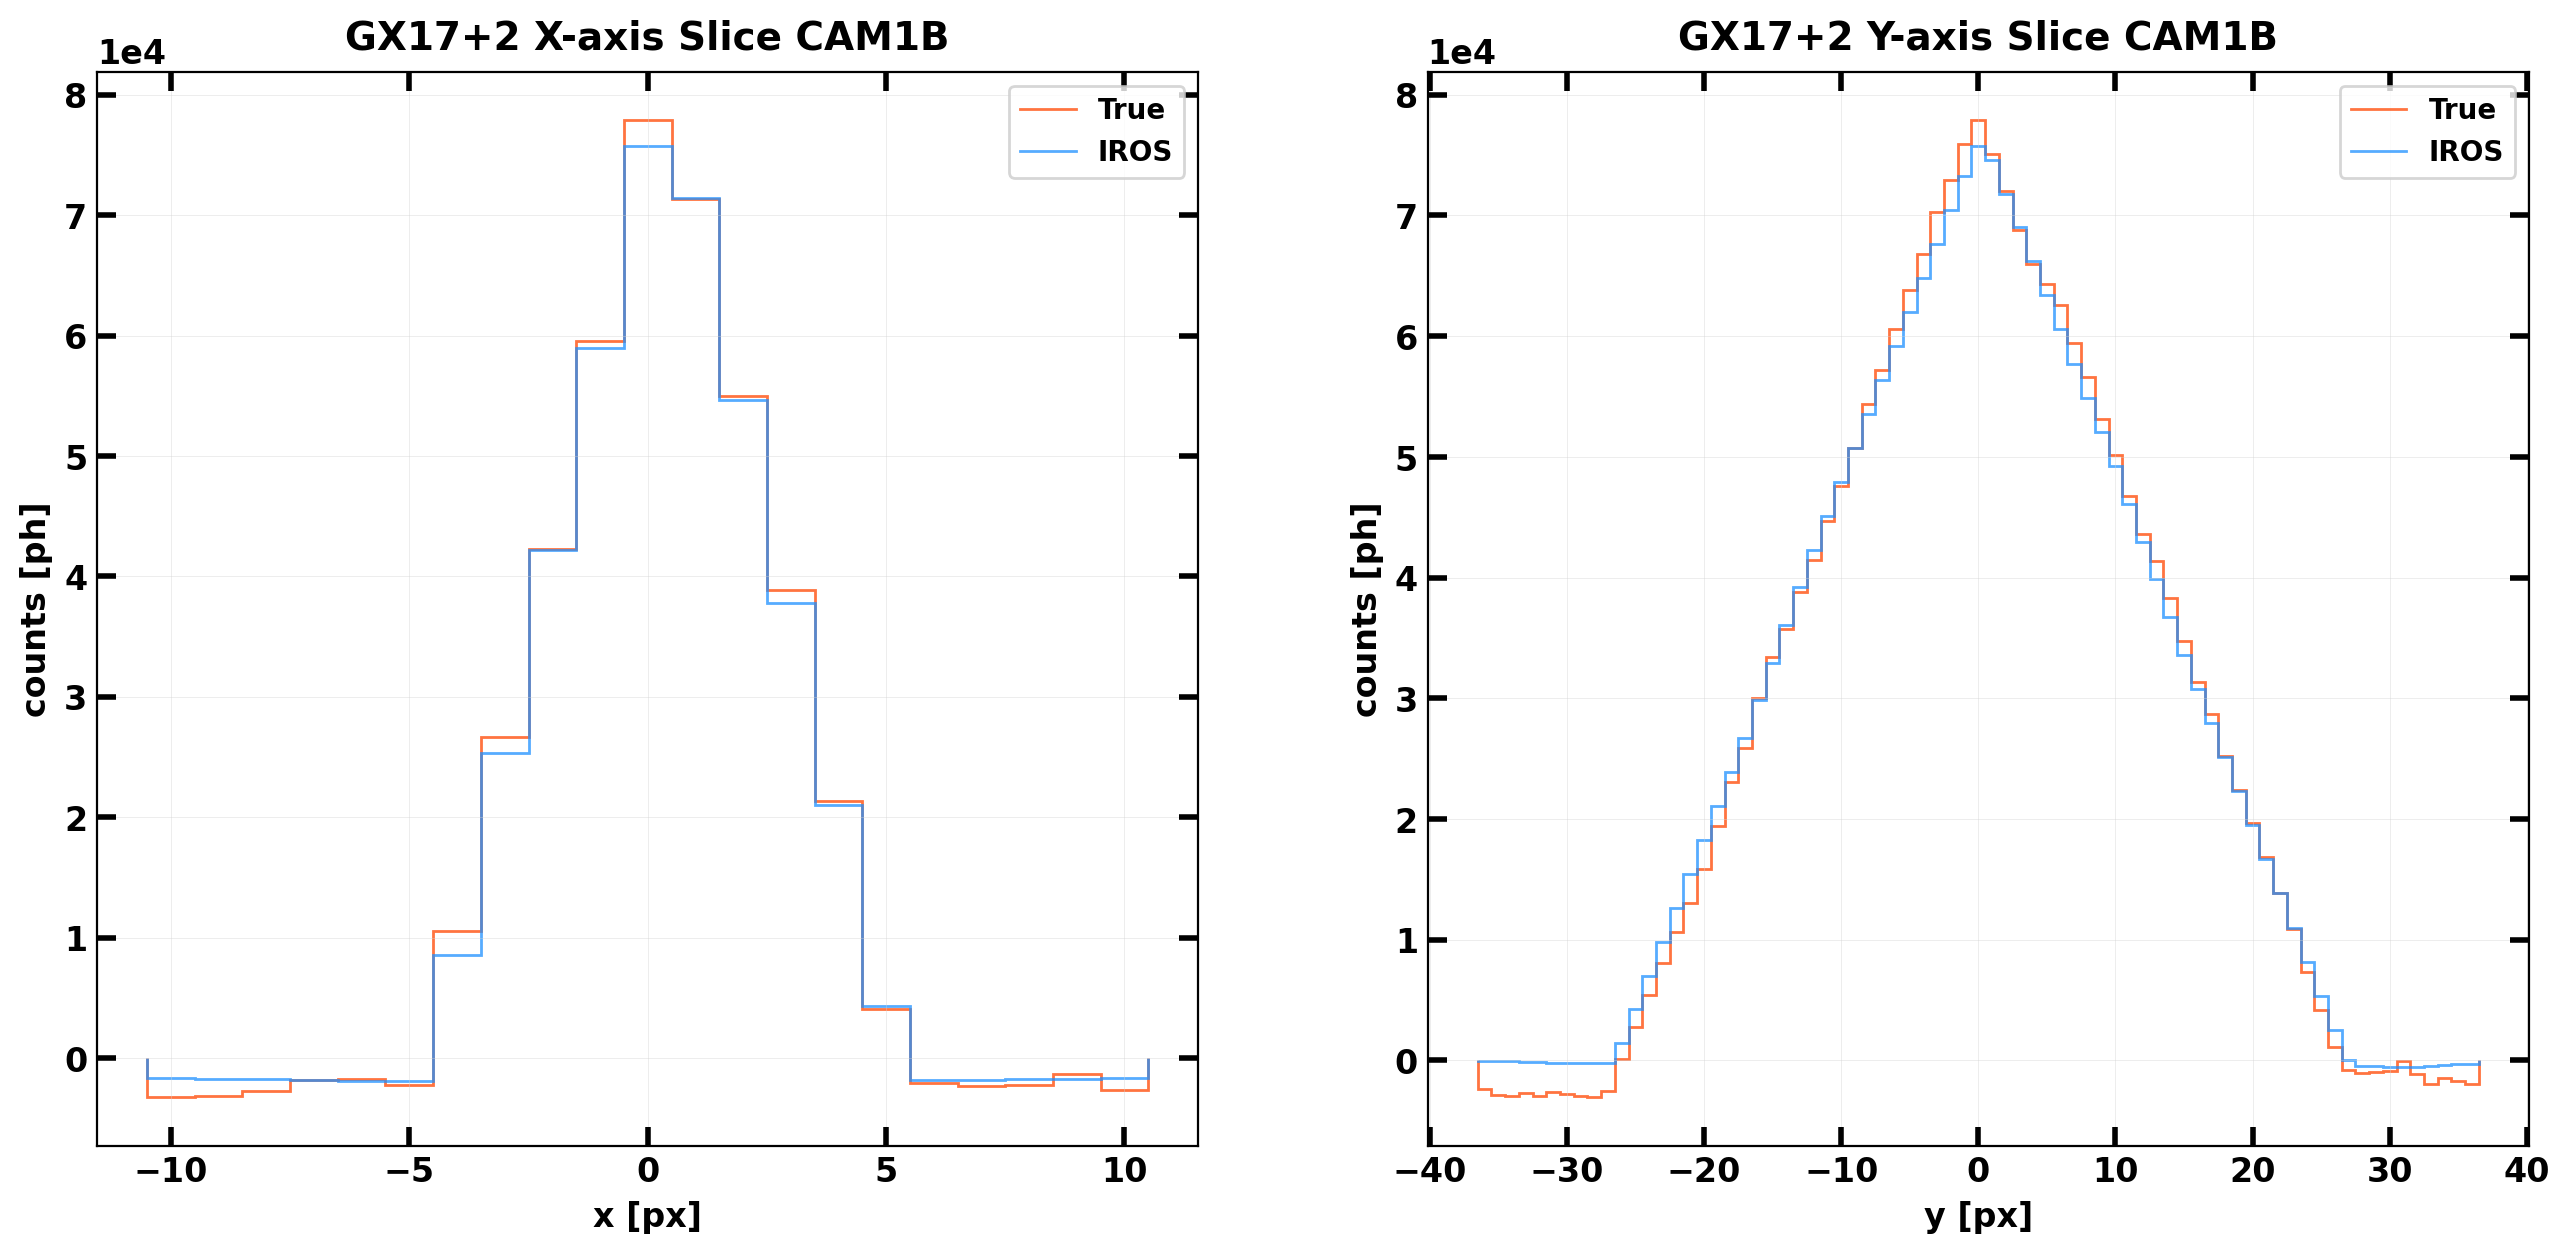

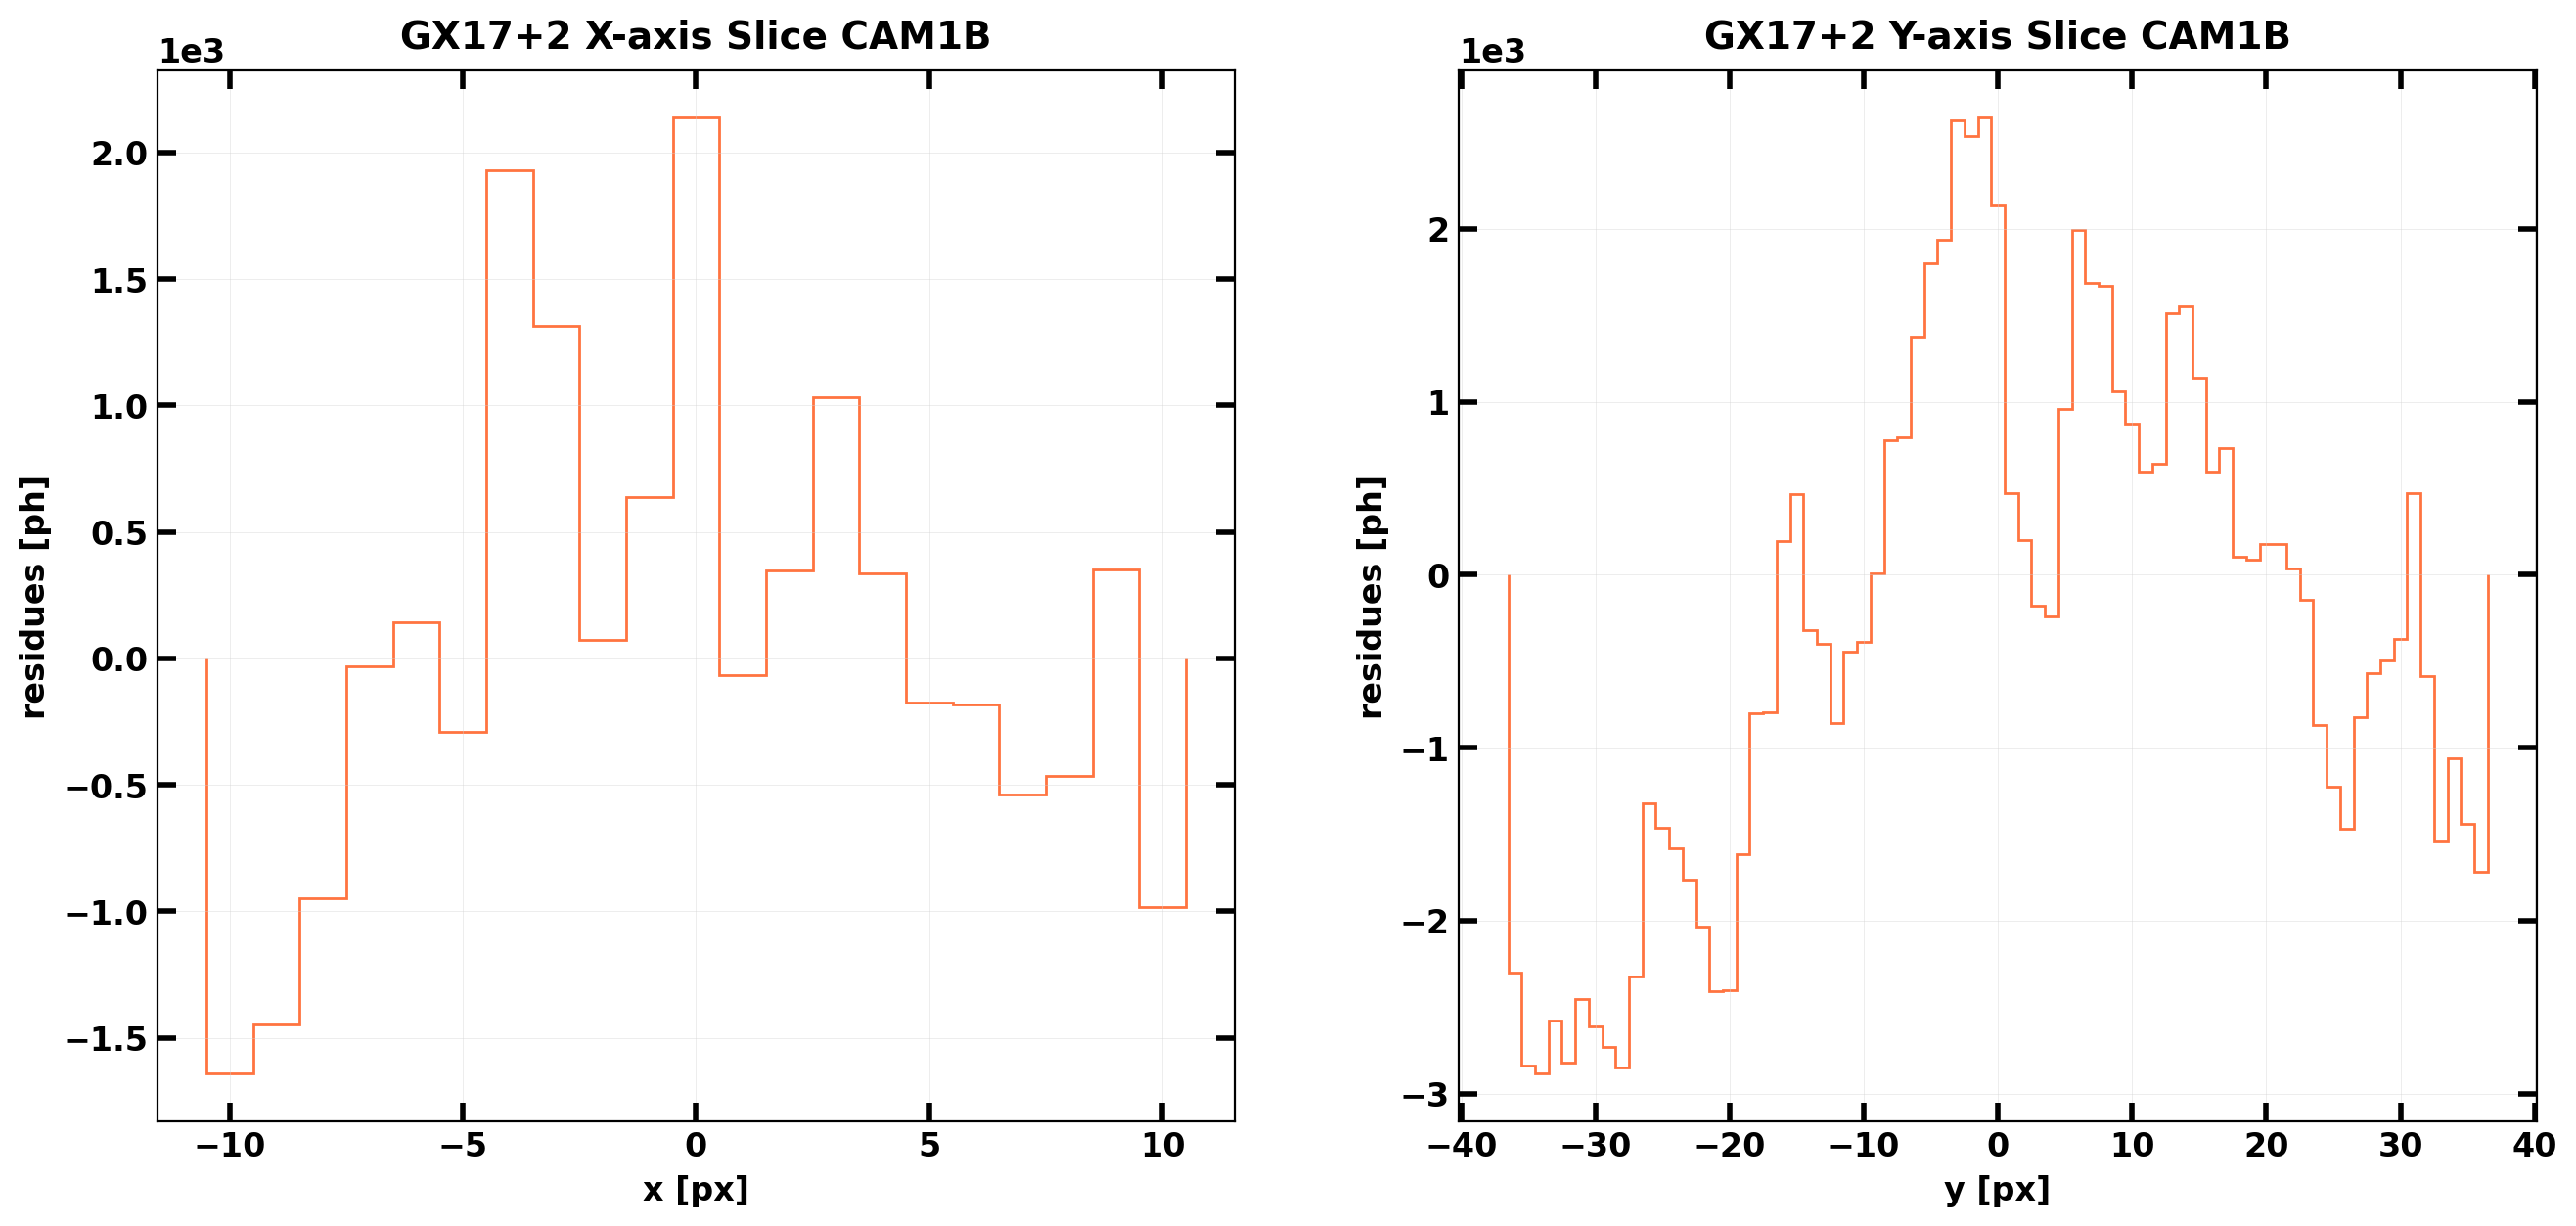

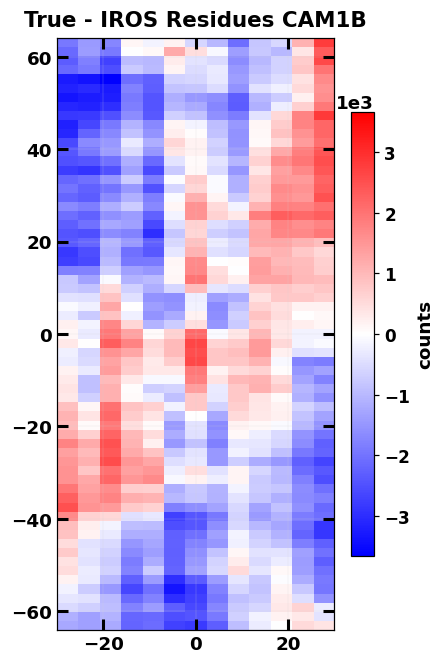

In [14]:
reconstruction_plot(
    true_sky=simul_sky_camB,
    log=log_camB,
    crp=(cropy, cropx),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    #savepath=is_img,
)

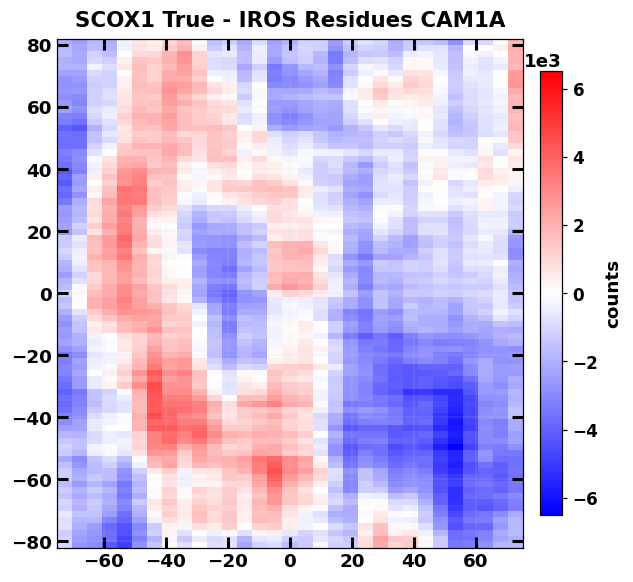

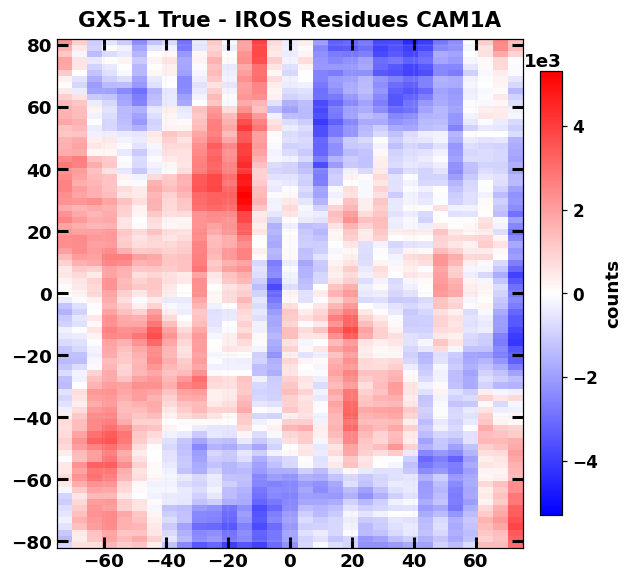

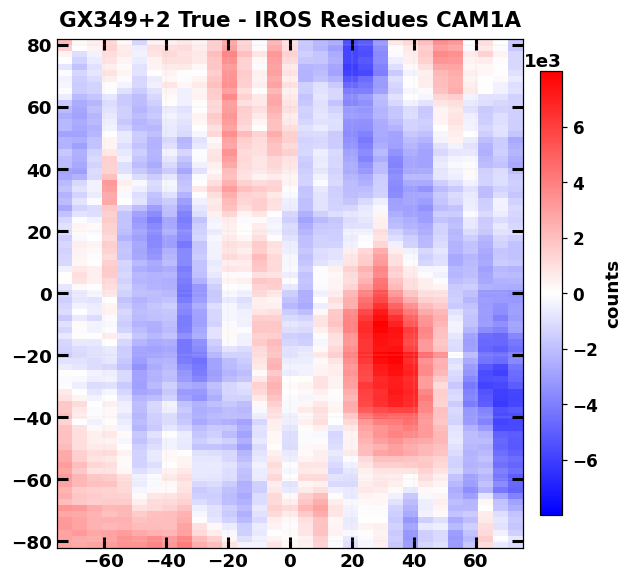

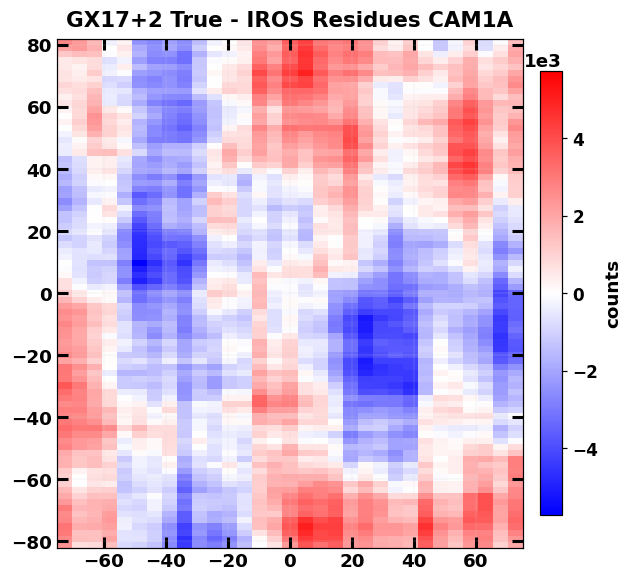

In [15]:
def reconstruction_HMs(
    true_sky: NDArray,
    log: Log,
    camera: CodedMaskCamera,
    *,
    vignetting: bool = True,
    psfy: bool = True,
    save_to: str | Path | None = None,
) -> None:
    """
    Displays the IROS reconstruction effect wrt the original decoded sky.
    """
    true_sky_ = true_sky.copy()
    UPX, UPY = camera.upscale_f

    for source, sx, sy, f, x, y in zip(
        log.log['ID'],
        log.log['shift_x'],
        log.log['shift_y'],
        log.log['fluence'],
        log.log['x'],
        log.log['y'],
    ):
        POS = (y, x)

        # simulate source
        modeled = model_sky(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            fluence=f,
            vignetting=vignetting,
            psfy=psfy,
        ).astype(np.int32)

        # plot IROS vs True residues heatmaps
        CUT = (
            int(camera.specs['slit_deltay'] * UPY / camera.specs['mask_deltay']) + 10,
            int(camera.specs['slit_deltax'] * UPX / camera.specs['mask_deltax']) + 10,
        )
        F_UPY, F_UPX = 2, 5

        true_crp, modeled_crp = map(
            lambda x: ds.crop(x, pos=POS, crp=CUT, strict=False),
            (true_sky_, modeled),
        )
        vlim = np.max(np.abs(true_crp - modeled_crp))
        ds.image_plot(
            dmaps=ds.map4image(
                img=ds.upscale(true_crp - modeled_crp, F_UPY, F_UPX) * np.prod((F_UPY, F_UPX)),
                title=f'{source.upper()} True - IROS Residues {log.name}',
                cbarlabel='counts',
                img_kwargs={
                    'vmin': -vlim,
                    'vmax': vlim,
                    'cmap': 'bwr',
                    'extent': (-CUT[1] * F_UPX, CUT[1] * F_UPX, -CUT[0] * F_UPY, CUT[0] * F_UPY),
                },
            ),
            save_to=save_to,
        )

        # remove source from True sky
        true_sky_ -= modeled


# see heat map of sky residuals around candidate pos
reconstruction_HMs(
    true_sky=simul_sky_camA,
    log=log_camA,
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    save_to=savefig_to(save_to, f'extendedHM_res_{cam_a.upper()}' + '_newpathinmask') if save_things else None,
)

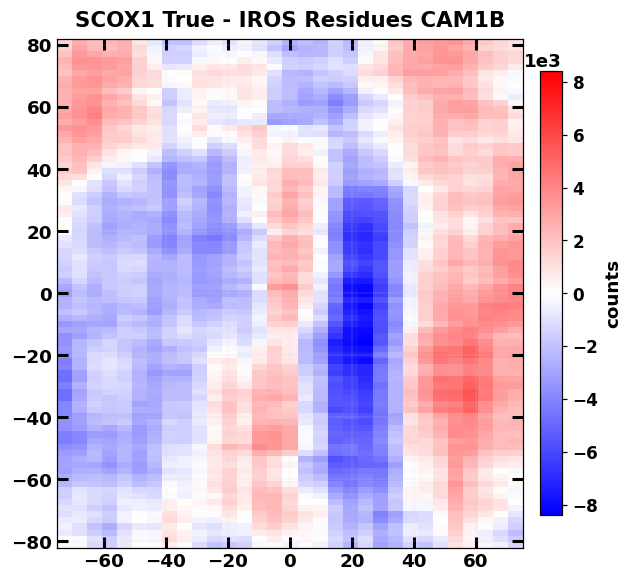

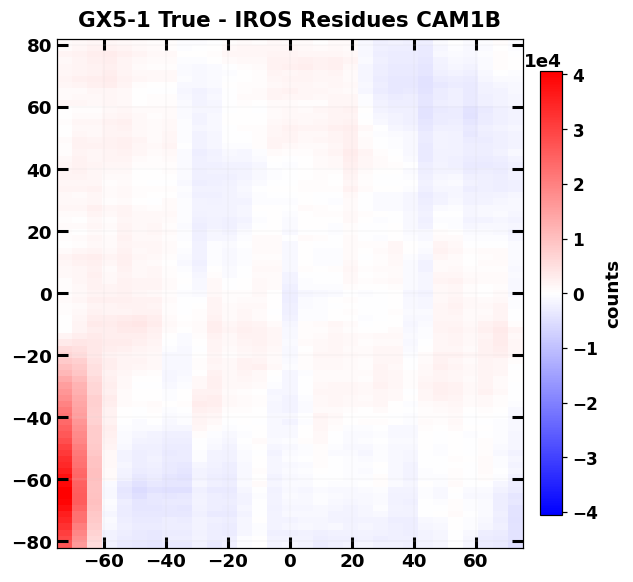

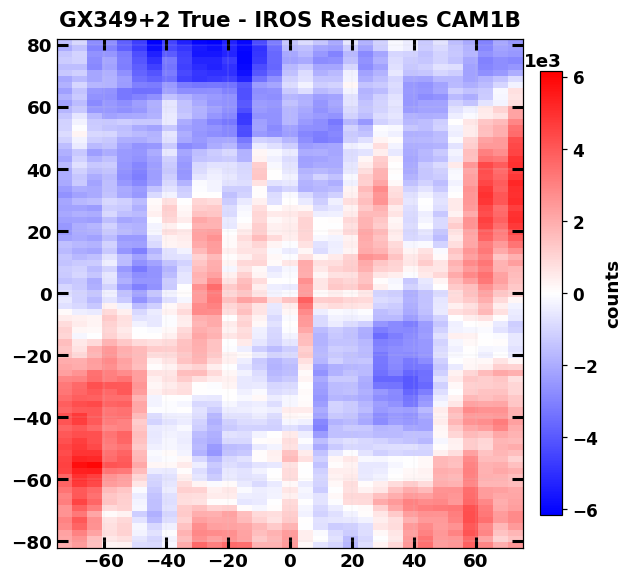

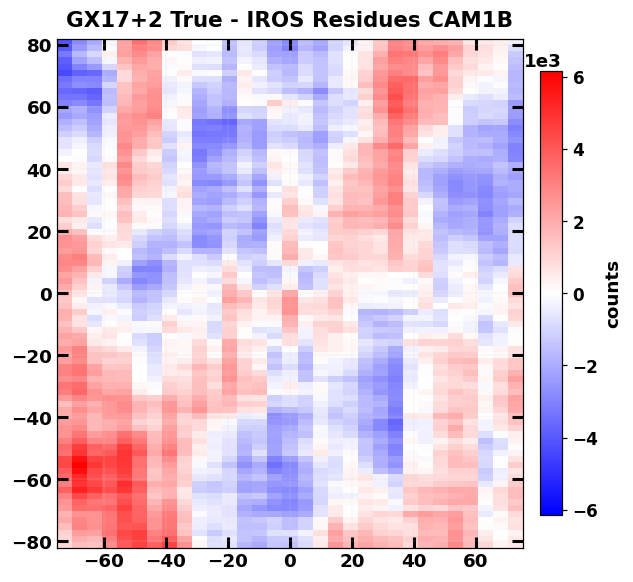

In [16]:
reconstruction_HMs(
    true_sky=simul_sky_camB,
    log=log_camB,
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    save_to=savefig_to(save_to, f'extendedHM_res_{cam_b.upper()}' + '_newpathinmask') if save_things else None,
)